# Complexity and Sensitivity Analysis

**Author:** Daniel González Espinosa

**Year:** 2026

**Binomial Tree Project**

---

### Environment Setup

We prepare the workspace by importing the standard mathematical libraries and every class from our local library that any section of this notebook will need — across all chapters, not just Chapter 1. This single cell covers the deterministic core of Chapter 1 (`RecombiningLattice`, `BinomialStockModel`, the `Payoff` hierarchy, `PricingEngine`/`ReducedStateEngine`), its probabilistic formalization in Chapter 2 (`CoinTossSpace` and the `stochastic_properties` validators), the state-price / optimal-investment machinery of Chapter 3 (`state_prices` and `optimal_investment`), and the American derivative securities machinery of Chapter 4 (`american_engine` — the early-exercise pricing engine and its consumption process — plus the two stopping-time utilities added to `stochastic_properties`, and the new path-dependent `RunningAveragePut` payoff). Running it once means no later section needs its own import cell.

The pricing engine we tested throughout Chapters 1-3 (`ReducedStateEngine`) implements state compression through node recombination. Chapter 4 reuses that exact same state-indexing technique in a new engine, `AmericanEngine`, which replaces the plain risk-neutral average with a `max` against the intrinsic value at every node — the only structural change the early-exercise feature requires.

In [1]:
import time
from itertools import product

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

from binomial_pricer.lattice import RecombiningLattice
from binomial_pricer.equity_model import BinomialStockModel
from binomial_pricer.payoffs import (EuropeanCall, EuropeanPut, Forward, LookbackOption, AsianOption,
                                      DelayedAsianOption, RunningAveragePut)
from binomial_pricer.engines import PricingEngine, ReducedStateEngine
from binomial_pricer.american_engine import AmericanEngine
from binomial_pricer.probability_space import CoinTossSpace
from binomial_pricer.stochastic_properties import (
    is_martingale, is_submartingale, is_supermartingale, is_markov,
    is_stopping_time, stop_process,
)
from binomial_pricer.state_prices import (
    radon_nikodym_derivative,
    state_price_density,
    price_via_state_prices,
    radon_nikodym_process,
    state_price_density_process,
    price_step_via_state_density_process,
)
from binomial_pricer.optimal_investment import (
    LogUtility,
    PowerUtility,
    GoalUtility,
    solve_optimal_investment,
    solve_goal_probability_maximization,
)

print("✅ Environment successfully configured.")
print("✅ Chapter 1 (deterministic core), Chapter 2 (probability space), Chapter 3 (state prices & optimal investment), "
      "and Chapter 4 (American derivatives & stopping times) classes imported successfully.")

✅ Environment successfully configured.
✅ Chapter 1 (deterministic core), Chapter 2 (probability space), Chapter 3 (state prices & optimal investment), and Chapter 4 (American derivatives & stopping times) classes imported successfully.


## Chapter 1 - Stochastic Calculus for Finance I: The Binomial Asset Pricing Model - Steven E. Shreve

### 1. Validation Against Shreve's Worked Example (Example 1.2.4)

Before exploring the model with generic parameters, we ground the engine in the
exact numerical example Shreve works through by hand in the book: $S_0=4$, $u=2$,
$d=0.5$, $r=0.25$, over three periods, pricing a lookback option. The book derives
$V_0=1.376$ step by step across Examples 1.2.4 and 1.3.2 — reproducing it here with
our own `ReducedStateEngine` is a direct check that the engine faithfully implements
the theory it claims to, not just a plausible-looking price.

In [2]:
shreve_model = BinomialStockModel(s0=4.0, u=2.0, d=0.5, r=0.25)
shreve_lookback = LookbackOption()

shreve_result = ReducedStateEngine().price(model=shreve_model, payoff=shreve_lookback, n_periods=3)

print("=== Reproducing Shreve, Example 1.2.4 / 1.3.2 (Lookback Option) ===")
print(f"V0 computed      : {shreve_result.v0:.4f}")
print(f"V0 in Shreve     : 1.3760")
print(f"Delta0 computed  : {shreve_result.delta0:.4f}")
print(f"Delta0 in Shreve : 0.1733")

assert abs(shreve_result.v0 - 1.376) < 1e-3, "Mismatch against Shreve's own worked example!"
print("\n✅ Engine output matches the book exactly.")

=== Reproducing Shreve, Example 1.2.4 / 1.3.2 (Lookback Option) ===
V0 computed      : 1.3760
V0 in Shreve     : 1.3760
Delta0 computed  : 0.1733
Delta0 in Shreve : 0.1733

✅ Engine output matches the book exactly.


### 2. No-Arbitrage Condition (Ref: Shreve Exercise 1.1)

The first pillar of the binomial model is to ensure that the mathematical configuration of the market does not allow for "riskless profits," that is, it excludes arbitrage. For a model with an up factor $u$, a down factor $d$, and a risk-free interest rate $r$, the fundamental pricing theorem strictly requires that

$$0 < d < 1+r < u.$$

If we violate these analytical boundaries, the market structure collapses financially:

* **If $d \geq 1+r$:** Arbitrage exists by borrowing money from the bank at rate $r$ to invest it entirely in the stock, guaranteeing a net profit.
* **If $u \leq 1+r$:** Arbitrage exists by short-selling the stock to deposit the capital in the bank at rate $r$.

Below, we computationally visualize the valid parameter space for a rate $r$ of 5%.

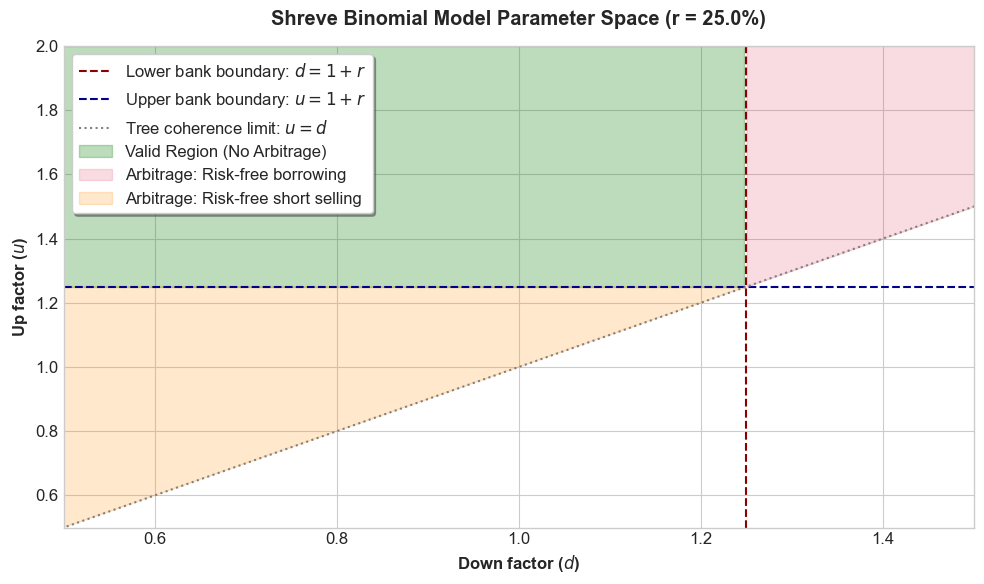

Architecture stress test (Arbitrage Boundaries):
✅ Successful arbitrage block: Arbitrage condition violated: d (1.3) >= 1+r (1.25). 


In [3]:
r = 0.25
risk_free_threshold = 1 + r

d_values = np.linspace(0.1, 1.5, 500)
u_max = 2.0

fig, ax = plt.subplots()

ax.axvline(x=risk_free_threshold, color='darkred', linestyle='--',
label=r'Lower bank boundary: $d = 1+r$')
ax.axhline(y=risk_free_threshold, color='darkblue', linestyle='--',
label=r'Upper bank boundary: $u = 1+r$')
ax.plot([0.1, u_max], [0.1, u_max], color='gray', linestyle=':',
label=r'Tree coherence limit: $u = d$')

ax.fill_between(d_values, risk_free_threshold, u_max,
where=(d_values < risk_free_threshold),
color='forestgreen', alpha=0.3,
label='Valid Region (No Arbitrage)')

ax.fill_between(d_values, d_values, u_max,
where=(d_values >= risk_free_threshold),
color='crimson', alpha=0.15,
label='Arbitrage: Risk-free borrowing')

ax.fill_between(d_values, d_values, risk_free_threshold,
where=(d_values < risk_free_threshold),
color='darkorange', alpha=0.2,
label='Arbitrage: Risk-free short selling')

ax.set_xlim(0.5, 1.5)
ax.set_ylim(0.5, 2.0)
ax.set_xlabel('Down factor ($d$)', fontweight='bold')
ax.set_ylabel('Up factor ($u$)', fontweight='bold')
ax.set_title(f'Shreve Binomial Model Parameter Space (r = {r*100}%)',
fontweight='bold', pad=15)
ax.legend(loc='upper left', frameon=True, shadow=True)

plt.tight_layout()
plt.show()

print("Architecture stress test (Arbitrage Boundaries):")

try:
    invalid_model = BinomialStockModel(s0=4, u=2.0, d=1.30, r=0.25)
except ValueError as e:
    print(f"✅ Successful arbitrage block: {e}")

### 3. The Risk-Neutral Probability Measure ($\tilde{p}$)

The core of Shreve's pricing theorem lies in the construction of a risk-neutral probability measure ($\tilde{p}$).

The fundamental equation for the probability of an upward trajectory in the binomial model is

$$\tilde{p} = \frac{1+r-d}{u-d}.$$

It is crucial to observe that the historical or real probability of the market going up ($p$) does not appear in this formula. The price of a derivative does not depend on our expectations about the market direction, but solely on the no-arbitrage structure dictated by $u$, $d$, and $r$.

Next, we fix the volatility of the underlying asset (through $u$ and $d$) and evaluate how $\tilde{p}$ evolves against variations in the interest rate $r$. To maintain mathematical consistency, $r$ will vary strictly within the no-arbitrage limits ($d < 1+r < u$).

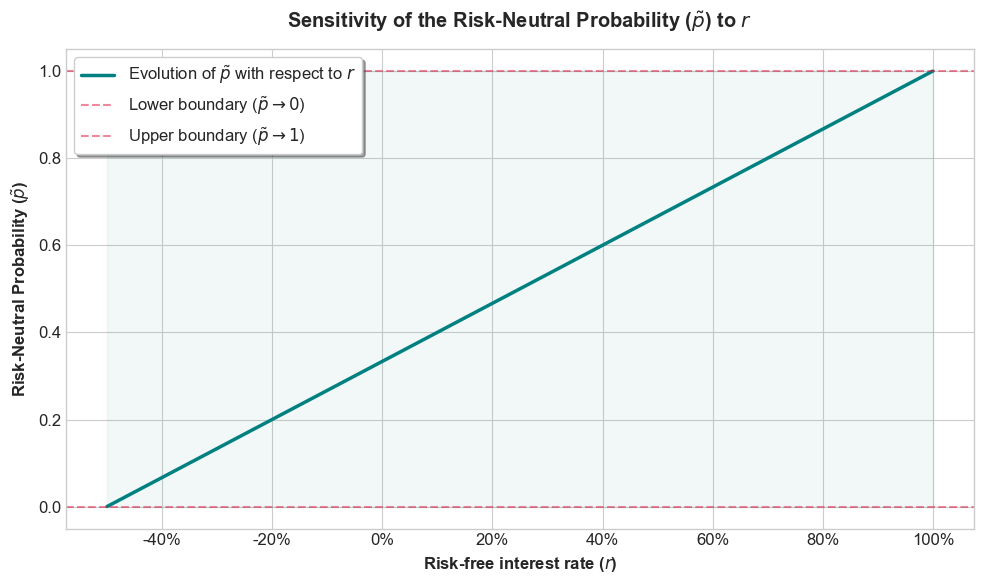

In [4]:
u = 2.00
d = 0.50

r_min = d - 1
r_max = u - 1

epsilon = 0.001
r_values = np.linspace(r_min + epsilon, r_max - epsilon, 200)


p_tilde_values = []
for r_val in r_values:
    test_model = BinomialStockModel(s0=100.0, u=u, d=d, r=r_val)
    
    p_tilde, q_tilde = test_model.risk_neutral_prob
    p_tilde_values.append(p_tilde)

fig, ax = plt.subplots()

ax.plot(r_values, p_tilde_values, color='teal', linewidth=2.5, 
        label=r'Evolution of $\tilde{p}$ with respect to $r$')

ax.axhline(y=0, color='crimson', linestyle='--', alpha=0.5, 
           label=r'Lower boundary ($\tilde{p} \to 0$)')
ax.axhline(y=1, color='crimson', linestyle='--', alpha=0.5, 
           label=r'Upper boundary ($\tilde{p} \to 1$)')

ax.fill_between(r_values, 0, 1, color='teal', alpha=0.05)

ax.set_title(r'Sensitivity of the Risk-Neutral Probability ($\tilde{p}$) to $r$', 
             fontweight='bold', pad=15)
ax.set_xlabel('Risk-free interest rate ($r$)', fontweight='bold')
ax.set_ylabel(r'Risk-Neutral Probability ($\tilde{p}$)', fontweight='bold')

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

ax.legend(loc='upper left', frameon=True, shadow=True)

plt.tight_layout()
plt.show()

### 4. Price Sensitivity and Delta Hedging ($\Delta$)

Having demonstrated the consistency of the theoretical boundaries (no-arbitrage and the risk-neutral measure), we proceed to instantiate the core architecture of our `binomial_pricer` library.

According to Shreve's fundamental pricing theorem, the price of a derivative $V_0$ is determined by calculating the discounted expected value under the measure $\tilde{p}$. Simultaneously, the model allows us to calculate the exact position in the underlying asset $\Delta_0$ that forms the replicating portfolio and neutralizes market risk. The Delta sensitivity at the initial node is defined by the discrete derivative

$$\Delta_0 = \frac{V_1(H) - V_1(T)}{S_1(H) - S_1(T)}.$$

We couple `BinomialStockModel` with `ReducedStateEngine` to price a family of `EuropeanCall` options across a spectrum of strike prices ($K$). We will analyze the option's transition from a highly favorable exercise state to an unfavorable exercise state, evaluating how the price decays and how its initial hedge ratio adjusts.

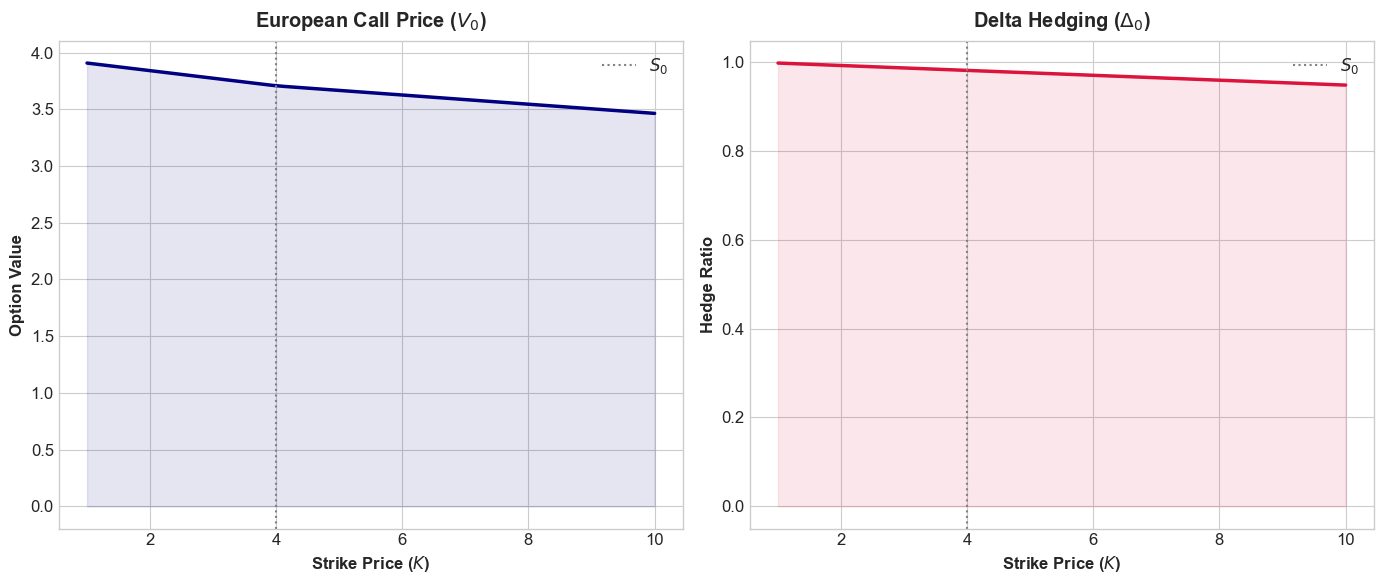

In [5]:
s0 = 4.00 
u = 2.00  
d = 0.50   
r = 0.25    
N = 10       

stock_model = BinomialStockModel(s0, u, d, r)

pricing_engine = ReducedStateEngine()

strikes = np.linspace(1.0, 10.0, 50)
prices_V0 = []
deltas_0 = []

for K in strikes:

    european_call = EuropeanCall(strike=K)

    result = pricing_engine.price(model=stock_model, payoff=european_call, n_periods=N)
    
    prices_V0.append(result.v0)
    deltas_0.append(result.delta0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.plot(strikes, prices_V0, color='navy', linewidth=2.5)
ax1.axvline(x=s0, color='gray', linestyle=':', label='$S_0$')
ax1.set_title(r'European Call Price ($V_0$)', fontweight='bold', pad=10)
ax1.set_xlabel('Strike Price ($K$)', fontweight='bold')
ax1.set_ylabel('Option Value', fontweight='bold')
ax1.fill_between(strikes, prices_V0, color='navy', alpha=0.1)
ax1.legend()

ax2.plot(strikes, deltas_0, color='crimson', linewidth=2.5)
ax2.axvline(x=s0, color='gray', linestyle=':', label='$S_0$')
ax2.set_title(r'Delta Hedging ($\Delta_0$)', fontweight='bold', pad=10)
ax2.set_xlabel('Strike Price ($K$)', fontweight='bold')
ax2.set_ylabel('Hedge Ratio', fontweight='bold')
ax2.fill_between(strikes, deltas_0, color='crimson', alpha=0.1)
ax2.legend()

plt.tight_layout()
plt.show()

### 5. The Path Challenge: Lookback vs. Asian Options

When introducing path-dependent options, the risk-neutral pricing principle requires expanding our state space. It is no longer enough to know the current price of the underlying ($S_n$); we need an additional state variable, $m$, that captures the relevant historical information of the path.

This project defines this transition through the abstract interface `PathDependentPayoff`, delegating to the derived class the definition of the methods `initial_aggregate()`, `update_aggregate()`, and `terminal_value()`. However, the nature of $m$ dictates whether the binomial tree is computationally tractable:

1. **Lookback Option:**
For a Lookback option, the state variable is the historical maximum: $M_n = \max_{0 \le i \le n} S_i$. In a tree where the up and down factors are constant ($u, d$), the price $S_n$ takes discrete values on a grid (lattice). Consequently, multiple paths that converge to the same price $S_n$ also share the same maximum $M_n$. This convergence allows our `ReducedStateEngine` to collapse redundant branches, keeping the algorithmic complexity manageable.
2. **Arithmetic Asian Option (The sum does not recombine):**
For a standard Asian option, the state variable is the accumulated sum: $Y_n = \sum_{i=0}^n S_i$. Unlike the maximum, the exact order in which the ups and downs occur alters the value of the intermediate prices and, therefore, alters the total sum. For example, an (Up, Down) path versus a (Down, Up) path ends at the same $S_2$, but generates a different $Y_2$. Since almost no paths share the same $Y_n$, the tree does not recombine, and the number of states grows at an unsustainable rate of $O(2^N)$.

Below, we validate the tractability of the Lookback option. We take $N=15$ and analyze the generated keys (`StateKey`) to demonstrate the state reduction compared to brute-force enumeration.

In [6]:
s0 = 4.00 
u = 2.00  
d = 0.50   
r = 0.25  
N = 15  

stock_model = BinomialStockModel(s0, u, d, r)
lookback_option = LookbackOption()
reduced_engine = ReducedStateEngine()

lookback_result = reduced_engine.price(model=stock_model, payoff=lookback_option, n_periods=N)

states_n15 = [key for key in lookback_result.value_grid.keys() if key[0] == N]
num_real_states = len(states_n15)
total_paths = 2 ** N

print("=== COMPLEXITY ANALYSIS (N = 15) ===")
print(f"Possible paths (Enumeration $O(2^N)$): {total_paths:,}")
print(f"Unique computed states at n=15:            {num_real_states:,}")
print(f"Algorithm compression factor:           {total_paths / num_real_states:.2f}x\n")

print("=== STATE CONVERGENCE DEMONSTRATION ===")
s_intermediate = s0 * (u**8) * (d**7)

states_same_spot = [
    key for key in states_n15 
    if np.isclose(key[1], s_intermediate)
]

states_same_spot.sort(key=lambda x: x[2])

print(f"Reaching the final price s_15 = {s_intermediate:.2f}, the tree only records the following states:")
for n, s, m in states_same_spot:
    print(f" -> Key: (n={n}, s_n={s:.2f}, Maximum={m:.2f})")

print(f"\nConclusion: Out of the thousands of paths that end at s_15 = {s_intermediate:.2f}, ")
print(f"the history of maximums ('m') converges into only {len(states_same_spot)} distinct variations.")

=== COMPLEXITY ANALYSIS (N = 15) ===
Possible paths (Enumeration $O(2^N)$): 32,768
Unique computed states at n=15:            72
Algorithm compression factor:           455.11x

=== STATE CONVERGENCE DEMONSTRATION ===
Reaching the final price s_15 = 8.00, the tree only records the following states:
 -> Key: (n=15, s_n=8.00, Maximum=8.00)
 -> Key: (n=15, s_n=8.00, Maximum=16.00)
 -> Key: (n=15, s_n=8.00, Maximum=32.00)
 -> Key: (n=15, s_n=8.00, Maximum=64.00)
 -> Key: (n=15, s_n=8.00, Maximum=128.00)
 -> Key: (n=15, s_n=8.00, Maximum=256.00)
 -> Key: (n=15, s_n=8.00, Maximum=512.00)
 -> Key: (n=15, s_n=8.00, Maximum=1024.00)

Conclusion: Out of the thousands of paths that end at s_15 = 8.00, 
the history of maximums ('m') converges into only 8 distinct variations.


### 6. Complexity Analysis: $O(2^N)$ vs $O(N^2)$

Derivative pricing via binomial trees faces an insurmountable computational wall if implemented naively. The `RecombiningLattice` class, through its `enumerate_paths()` method, represents the purely combinatorial approach of the iterative process. For a number of periods $N$, the engine must evaluate $2^N$ possible sequences. This makes the model mathematically correct, but algorithmically intractable for any sufficiently large $N$.

In contrast, the object-oriented architecture of the `ReducedStateEngine` implements the state space compression described by Shreve. By recognizing that in a standard tree the number of distinct price nodes at time $n$ is $n+1$, the space and time complexity for path-independent options (such as the European Call) is reduced to an order of $O(N^2)$.

Below, we will perform a computational performance analysis by subjecting our engine to a stress test with increasing values of $N$ (up to 1000 periods). This will demonstrate how state abstraction transforms an unsolvable exponential problem into a computation that finishes in fractions of a second.

Evaluating ReducedStateEngine (European Call)...

 -> Depth N =   10 | Time: 0.000492 seconds
 -> Depth N =   50 | Time: 0.014599 seconds
 -> Depth N =  100 | Time: 0.036141 seconds
 -> Depth N =  250 | Time: 0.244728 seconds
 -> Depth N =  500 | Time: 1.874586 seconds
 -> Depth N = 1000 | Time: 9.319648 seconds


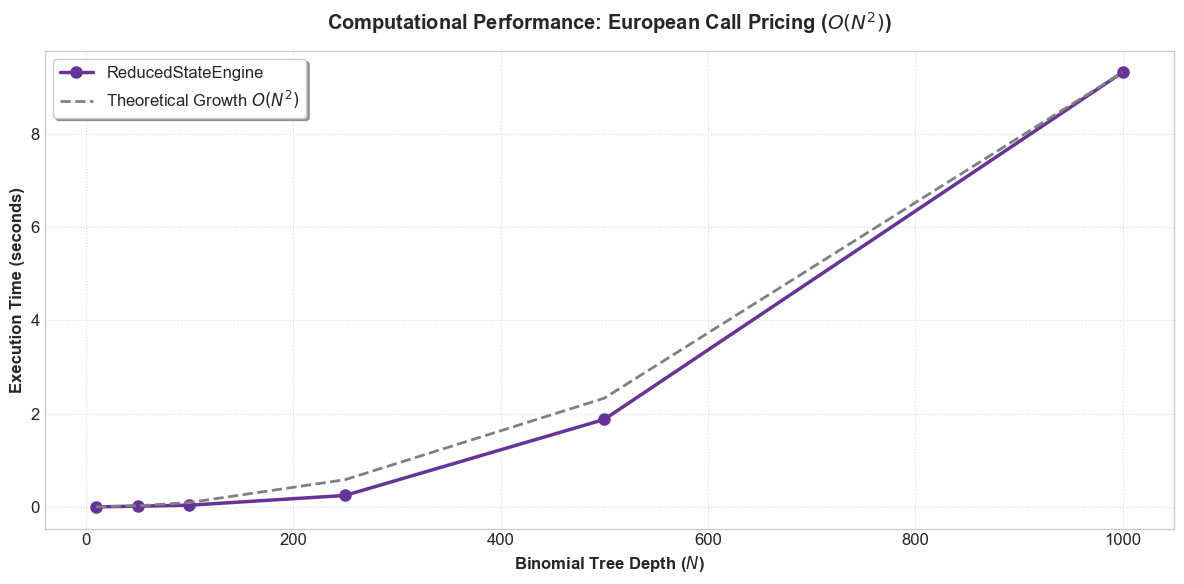

In [7]:
s0 = 4.00 
u = 2.00  
d = 0.50   
r = 0.25 

stock_model = BinomialStockModel(s0, u, d, r)
european_call = EuropeanCall(strike=5.0)
reduced_engine = ReducedStateEngine()

N_values = [10, 50, 100, 250, 500, 1000]
execution_times = []

print("Evaluating ReducedStateEngine (European Call)...\n")

for N in N_values:
    start = time.perf_counter()
    
    _ = reduced_engine.price(model=stock_model, payoff=european_call, n_periods=N)
    
    end = time.perf_counter()
    elapsed_time = end - start
    execution_times.append(elapsed_time)
    
    print(f" -> Depth N = {N:4d} | Time: {elapsed_time:.6f} seconds")

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(N_values, execution_times, marker='o', color='rebeccapurple', 
        linewidth=2.5, markersize=8, label='ReducedStateEngine')

scale_factor = execution_times[-1] / (N_values[-1] ** 2)
theoretical_times_n2 = [scale_factor * (n ** 2) for n in N_values]

ax.plot(N_values, theoretical_times_n2, color='gray', linestyle='--', 
        linewidth=2, label=r'Theoretical Growth $O(N^2)$')

ax.set_title(r'Computational Performance: European Call Pricing ($O(N^2)$)', 
             fontweight='bold', pad=15)
ax.set_xlabel('Binomial Tree Depth ($N$)', fontweight='bold')
ax.set_ylabel('Execution Time (seconds)', fontweight='bold')

ax.grid(True, linestyle=':', alpha=0.7)
ax.legend(loc='upper left', frameon=True, shadow=True)

plt.tight_layout()
plt.show()

## Chapter 2 - Stochastic Calculus for Finance I: Probability Theory on Coin Toss Space - Steven E. Shreve

Having validated the deterministic core of the binomial model — no-arbitrage, risk-neutral pricing, and state-space reduction — we now turn to formalizing the probabilistic machinery that Chapter 1 used implicitly. Chapter 2 of Shreve builds the finite probability space $(\Omega, \mathbb{P})$ underlying the coin-toss model, defines conditional expectation as it updates estimates over time, and uses both to prove that the pricing formulas of Chapter 1 are **martingales** under $\tilde{\mathbb{P}}$ — the deep reason no-arbitrage pricing works at all, not just a computational coincidence.

This section extends `binomial_pricer` with two new modules:
- `probability_space.py` — the `CoinTossSpace` class, encapsulating $\Omega_N$, its probability measure, distribution, expectation, and conditional expectation (Sections 2.1–2.3).
- `stochastic_properties.py` — `is_martingale`, `is_submartingale`, `is_supermartingale`, and `is_markov`: computational validators for the properties Shreve proves by hand (Sections 2.4–2.5).

### 1. The Probability Space $\Omega_N$: Actual vs. Risk-Neutral Measure

Chapter 1 already used a probability measure implicitly — $\tilde{p}$ appears throughout the pricing formulas — but never defined $\Omega$ or $\mathbb{P}$ as objects in their own right. Section 2.1 does exactly that: $\Omega_N$ is the finite set of all coin-toss sequences of length $N$, and $\mathbb{P}(\omega) = p^{\#H(\omega)}q^{\#T(\omega)}$ assigns each path a probability (Eq. 2.1.2 for the enumerated case, generalized in Eq. 2.3.6).

Crucially, this $p$ need not be the risk-neutral $\tilde{p}$ from Chapter 1 — it can be the *actual* (real-world, subjective) probability of an up-move. Exercise 2.2 asks exactly this: fix the tree ($S_0=4, u=2, d=0.5$), and compare the distribution and expectation of $S_3$ under $\tilde{p}=0.5$ against the actual $p=2/3$.

The support of $S_3$ (the set of prices it can reach) is identical under both measures — it only depends on $u, d, N$. What changes is how much probability mass sits on each value, and therefore the mean growth rate.

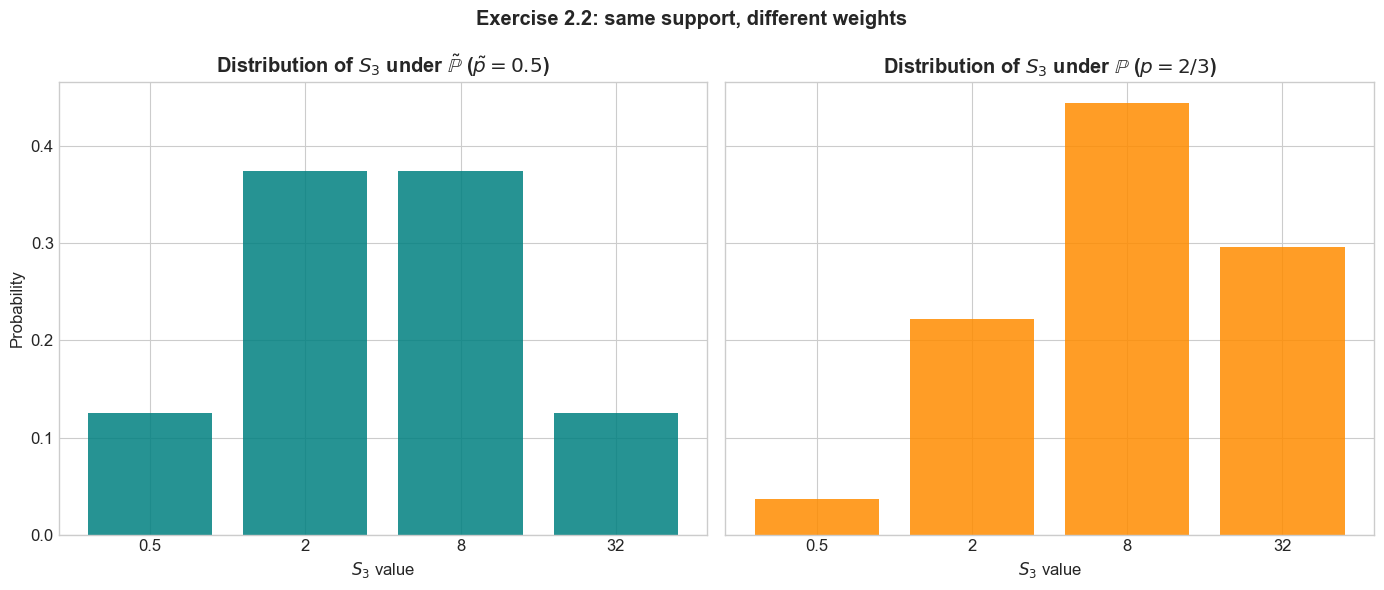

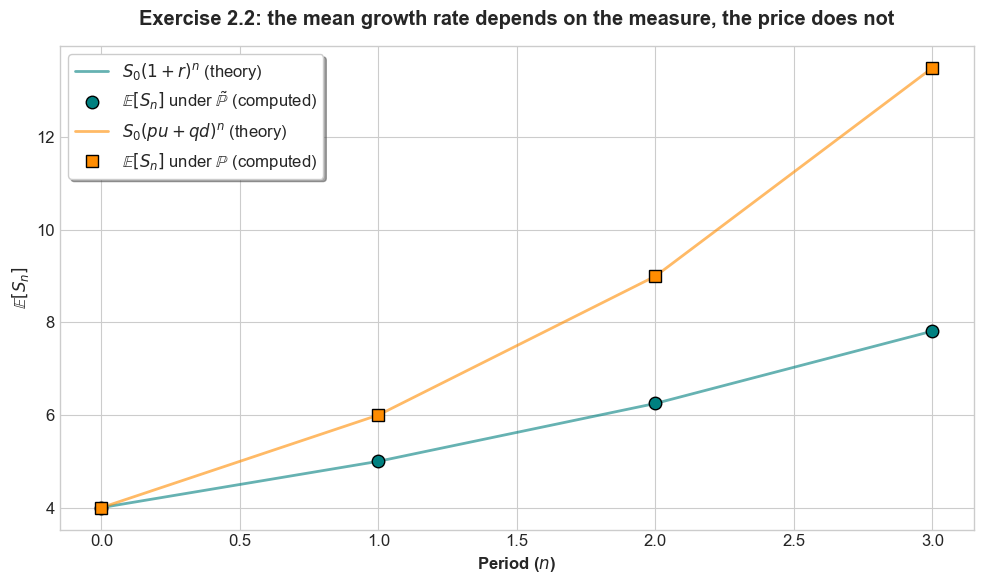

Max |computed - theory| under P̃: 0.00e+00   (machine precision -> Theorem 2.4.4 holds exactly)
Max |computed - theory| under P:  0.00e+00   (machine precision -> i.i.d. drift holds exactly)


In [8]:
N = 3
s0, u, d, r = 4.0, 2.0, 0.5, 0.25
stock_model = BinomialStockModel(s0=s0, u=u, d=d, r=r)

p_tilde, _ = stock_model.risk_neutral_prob   
p_real = 2 / 3                                

space_rn = CoinTossSpace(n_periods=N, p=p_tilde)
space_real = CoinTossSpace(n_periods=N, p=p_real)

omega = space_rn.get_omega()
S = {n: {w: stock_model.price_path(w)[n] for w in omega} for n in range(N + 1)}

dist_rn_s3 = space_rn.distribution(S[N])
dist_real_s3 = space_real.distribution(S[N])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

values = sorted(dist_rn_s3.keys())
labels = [f"{v:g}" for v in values]

ax1.bar(labels, [dist_rn_s3[v] for v in values], color='teal', alpha=0.85)
ax1.set_title(r'Distribution of $S_3$ under $\tilde{\mathbb{P}}$ ($\tilde{p}=0.5$)', fontweight='bold')
ax1.set_xlabel('$S_3$ value')
ax1.set_ylabel('Probability')

ax2.bar(labels, [dist_real_s3[v] for v in values], color='darkorange', alpha=0.85)
ax2.set_title(r'Distribution of $S_3$ under $\mathbb{P}$ ($p=2/3$)', fontweight='bold')
ax2.set_xlabel('$S_3$ value')

plt.suptitle('Exercise 2.2: same support, different weights', fontweight='bold')
plt.tight_layout()
plt.show()

mean_rn = [space_rn.expectation(S[n]) for n in range(N + 1)]
mean_real = [space_real.expectation(S[n]) for n in range(N + 1)]

theoretical_rn = [s0 * (1 + r) ** n for n in range(N + 1)]
mean_growth_real = p_real * u + (1 - p_real) * d
theoretical_real = [s0 * mean_growth_real ** n for n in range(N + 1)]

fig, ax = plt.subplots()

ax.plot(range(N + 1), theoretical_rn, '-', color='teal', linewidth=2, alpha=0.6,
        label=r'$S_0(1+r)^n$ (theory)')
ax.plot(range(N + 1), mean_rn, 'o', color='teal', markersize=9, markeredgecolor='black',
        label=r'$\mathbb{E}[S_n]$ under $\tilde{\mathbb{P}}$ (computed)')

ax.plot(range(N + 1), theoretical_real, '-', color='darkorange', linewidth=2, alpha=0.6,
        label=r'$S_0(pu+qd)^n$ (theory)')
ax.plot(range(N + 1), mean_real, 's', color='darkorange', markersize=9, markeredgecolor='black',
        label=r'$\mathbb{E}[S_n]$ under $\mathbb{P}$ (computed)')

ax.set_title('Exercise 2.2: the mean growth rate depends on the measure, the price does not',
             fontweight='bold', pad=15)
ax.set_xlabel('Period ($n$)', fontweight='bold')
ax.set_ylabel(r'$\mathbb{E}[S_n]$', fontweight='bold')
ax.legend(loc='upper left', frameon=True, shadow=True)
plt.tight_layout()
plt.show()

max_diff_rn = max(abs(a - b) for a, b in zip(mean_rn, theoretical_rn))
max_diff_real = max(abs(a - b) for a, b in zip(mean_real, theoretical_real))
print(f"Max |computed - theory| under P̃: {max_diff_rn:.2e}   (machine precision -> Theorem 2.4.4 holds exactly)")
print(f"Max |computed - theory| under P:  {max_diff_real:.2e}   (machine precision -> i.i.d. drift holds exactly)")

### 2. Conditional Expectation in Action: Confirming the Martingale Property

Theorem 2.4.4 states that under $\tilde{\mathbb{P}}$, the discounted stock price $S_n/(1+r)^n$ is a martingale: its conditional expectation one step ahead always equals its current value. Theorem 2.4.5 extends this to the discounted wealth process of *any* self-financing replicating portfolio — which is precisely what `PricingEngine`'s `delta_grid` builds, one node at a time, without ever invoking the word "martingale."

We reconstruct both processes explicitly from the engine's own output for the `EuropeanCall` already priced in Section 5, and hand them to `is_martingale` — turning a property Shreve proves algebraically into a property we can check computationally on our own pricing engine.

Discounted stock price is a martingale under P̃: True
Discounted self-financing wealth is a martingale under P̃: True


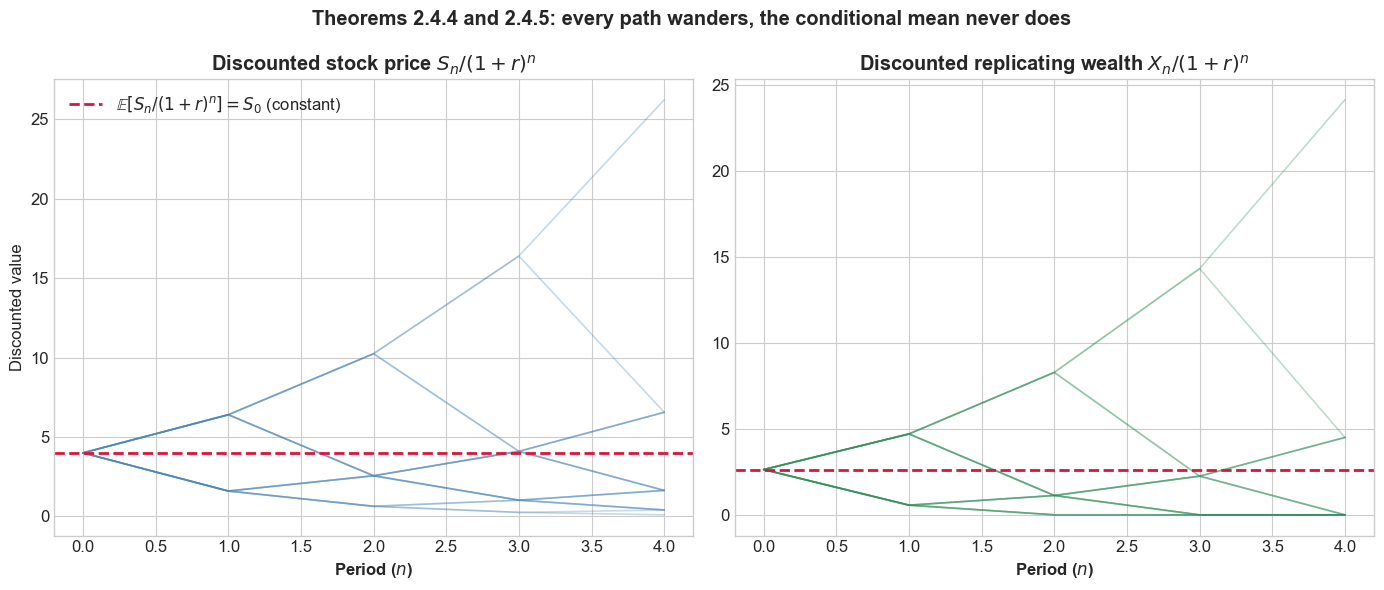


Root-node check (Theorem 2.4.4): S_0 = 4.0000   vs.   E_0[S_1]/(1+r) = 4.0000


In [9]:
N = 4
K = 5.0
call_test = EuropeanCall(strike=K)
result = PricingEngine().price(model=stock_model, payoff=call_test, n_periods=N)

p_tilde, q_tilde = stock_model.risk_neutral_prob
space = CoinTossSpace(n_periods=N, p=p_tilde)

discounted_S = []
for n in range(N + 1):
    prefixes = [""] if n == 0 else ["".join(seq) for seq in product("HT", repeat=n)]
    discounted_S.append({w: stock_model.price_path(w)[-1] / ((1 + r) ** n) for w in prefixes})

print("Discounted stock price is a martingale under P̃:", is_martingale(space, discounted_S))

X = [{"": result.v0}]
for n in range(1, N + 1):
    prefixes = ["".join(seq) for seq in product("HT", repeat=n)]
    layer = {}
    for w in prefixes:
        prev = w[:-1]
        delta_n = result.delta_grid[prev]
        X_prev = X[n - 1][prev]
        S_prev = stock_model.price_path(prev)[-1] if prev else s0
        S_curr = stock_model.price_path(w)[-1]
        layer[w] = delta_n * S_curr + (1 + r) * (X_prev - delta_n * S_prev)
    X.append(layer)

discounted_X = [{w: v / ((1 + r) ** n) for w, v in layer.items()} for n, layer in enumerate(X)]
print("Discounted self-financing wealth is a martingale under P̃:", is_martingale(space, discounted_X))

full_paths = ["".join(seq) for seq in product("HT", repeat=N)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharex=True)

for path in full_paths:
    y = [discounted_S[n][path[:n]] for n in range(N + 1)]
    ax1.plot(range(N + 1), y, color='steelblue', alpha=0.3, linewidth=1.2)
ax1.axhline(y=s0, color='crimson', linestyle='--', linewidth=2, label=r'$\mathbb{E}[S_n/(1+r)^n] = S_0$ (constant)')
ax1.set_title(r'Discounted stock price $S_n/(1+r)^n$', fontweight='bold')
ax1.set_xlabel('Period ($n$)', fontweight='bold')
ax1.set_ylabel('Discounted value')
ax1.legend(loc='upper left')

for path in full_paths:
    y = [discounted_X[n][path[:n]] for n in range(N + 1)]
    ax2.plot(range(N + 1), y, color='seagreen', alpha=0.3, linewidth=1.2)
ax2.axhline(y=result.v0, color='crimson', linestyle='--', linewidth=2, label=r'$\mathbb{E}[X_n/(1+r)^n] = X_0 = V_0$ (constant)')
ax2.set_title(r'Discounted replicating wealth $X_n/(1+r)^n$', fontweight='bold')
ax2.set_xlabel('Period ($n$)', fontweight='bold')

plt.suptitle('Theorems 2.4.4 and 2.4.5: every path wanders, the conditional mean never does', fontweight='bold')
plt.tight_layout()
plt.show()

S1_H, S1_T = stock_model.s1_h, stock_model.s1_t
lhs = s0
rhs = (p_tilde * S1_H + q_tilde * S1_T) / (1 + r)
print(f"\nRoot-node check (Theorem 2.4.4): S_0 = {lhs:.4f}   vs.   E_0[S_1]/(1+r) = {rhs:.4f}")

### 3. Convexity and Submartingales: Exercise 2.3 in Motion

Theorem 2.3.2(v) — the conditional Jensen's inequality — is usually stated as a single static formula: $\mathbb{E}_n[\varphi(X)] \ge \varphi(\mathbb{E}_n[X])$ for convex $\varphi$. Exercise 2.3 turns this into a dynamic claim about processes: if $M_n$ is a martingale and $\varphi$ is convex, then $\varphi(M_n)$ is a **submartingale** — its conditional mean can only drift upward, never stay flat or fall.

We use the symmetric random walk $M_n$ from Exercise 2.4 ($M_n = \sum_{j=1}^n X_j$, $X_j = \pm 1$ with equal probability) — a pure martingale by construction — and apply the convex function $\varphi(x) = x^2$. `is_martingale` and `is_submartingale` let us confirm computationally what Jensen guarantees analytically: $\mathbb{E}[M_n]$ stays flat at 0, while $\mathbb{E}[M_n^2]$ grows strictly with $n$ (in fact $\mathbb{E}[M_n^2] = n$ exactly, since $M_n$ is a sum of $n$ independent $\pm1$ steps).

M_n is a martingale:                  True
phi(M_n) = M_n^2 is a submartingale:  True
phi(M_n) = M_n^2 is NOT a martingale:  True


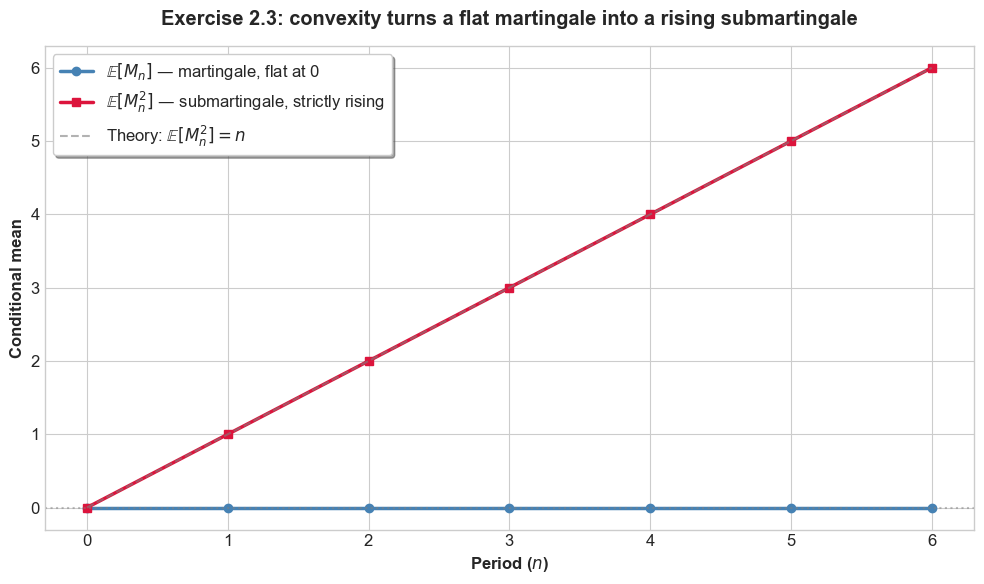

In [10]:
N = 6
space_rw = CoinTossSpace(n_periods=N, p=0.5)

M = [{"": 0.0}]
for n in range(1, N + 1):
    layer = {}
    for seq in product("HT", repeat=n):
        path = "".join(seq)
        layer[path] = sum(1.0 if c == 'H' else -1.0 for c in path)
    M.append(layer)

phi_M = [{w: v ** 2 for w, v in layer.items()} for layer in M]

print("M_n is a martingale:                 ", is_martingale(space_rw, M))
print("phi(M_n) = M_n^2 is a submartingale: ", is_submartingale(space_rw, phi_M))
print("phi(M_n) = M_n^2 is NOT a martingale: ", not is_martingale(space_rw, phi_M))

mean_M = [space_rw.expectation(M[n]) for n in range(N + 1)]
mean_phi_M = [space_rw.expectation(phi_M[n]) for n in range(N + 1)]
theoretical_variance = [float(n) for n in range(N + 1)]  # E[M_n^2] = n exactly

fig, ax = plt.subplots()
ax.plot(range(N + 1), mean_M, 'o-', color='steelblue', linewidth=2.5,
        label=r'$\mathbb{E}[M_n]$ — martingale, flat at 0')
ax.plot(range(N + 1), mean_phi_M, 's-', color='crimson', linewidth=2.5,
        label=r'$\mathbb{E}[M_n^2]$ — submartingale, strictly rising')
ax.plot(range(N + 1), theoretical_variance, '--', color='gray', alpha=0.6,
        label=r'Theory: $\mathbb{E}[M_n^2] = n$')
ax.axhline(y=0, color='gray', linestyle=':', alpha=0.5)

ax.set_title('Exercise 2.3: convexity turns a flat martingale into a rising submartingale',
             fontweight='bold', pad=15)
ax.set_xlabel('Period ($n$)', fontweight='bold')
ax.set_ylabel('Conditional mean', fontweight='bold')
ax.legend(loc='upper left', frameon=True, shadow=True)
plt.tight_layout()
plt.show()

### 4. When Two Paths Collide: The Markov Counterexample (Example 2.5.4)

Section 1.3 justified state-space reduction empirically: track $(S_n, M_n)$ instead of the full path, and the lookback tree recombines. Section 2.5 explains *why* this is legitimate — $(S_n, M_n)$ satisfies the Markov property (Definition 2.5.5), so a deterministic pricing function $v_n(s, m)$ is guaranteed to exist (Theorem 2.5.8).

But the running maximum $M_n$ *alone* is not enough. Example 2.5.4 gives the exact counterexample: in the model $S_0=4, u=2, d=0.5$ with actual probabilities $p=2/3, q=1/3$, the paths $TH$ and $TT$ both reach $M_2 = 4$ — the *same* state — yet lead to strictly different distributions of $M_3$. We reproduce the book's own numbers below, then visualize the collision directly.

M_n alone is Markov:    False
(S_n, M_n) is Markov:   True

M_2(TH) = 4.0   M_2(TT) = 4.0   -> same state: True
E_2[M_3](TH) = 0.667*8.0 + 0.333*4.0 = 6.6667
E_2[M_3](TT) = 0.667*4.0 + 0.333*4.0 = 4.0000

Same current state, different future expectation -> no function g(M_2) can exist -> not Markov.


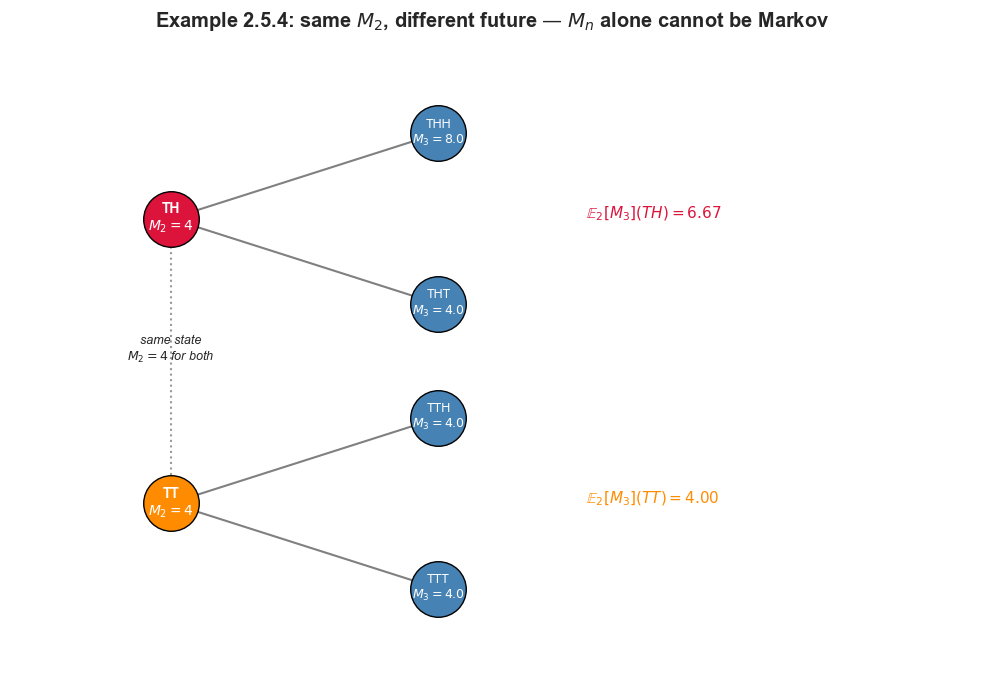

In [11]:
s0, u, d, r = 4.0, 2.0, 0.5, 0.25
stock_model = BinomialStockModel(s0=s0, u=u, d=d, r=r)
p_actual = 2 / 3
N = 3

space = CoinTossSpace(n_periods=N, p=p_actual)

process_1d, process_2d = [], []
for n in range(N + 1):
    layer_1d, layer_2d = {}, {}
    prefixes = [""] if n == 0 else ["".join(seq) for seq in product("HT", repeat=n)]
    for w in prefixes:
        prices = stock_model.price_path(w)
        m = max(prices)
        layer_1d[w] = m
        layer_2d[w] = (prices[-1], m)
    process_1d.append(layer_1d)
    process_2d.append(layer_2d)

print("M_n alone is Markov:   ", is_markov(space, process_1d))
print("(S_n, M_n) is Markov:  ", is_markov(space, process_2d))

M2_TH, M2_TT = process_1d[2]["TH"], process_1d[2]["TT"]
M3_THH, M3_THT = process_1d[3]["THH"], process_1d[3]["THT"]
M3_TTH, M3_TTT = process_1d[3]["TTH"], process_1d[3]["TTT"]

p, q = space.p, space.q
E2_M3_TH = p * M3_THH + q * M3_THT
E2_M3_TT = p * M3_TTH + q * M3_TTT

print(f"\nM_2(TH) = {M2_TH:.1f}   M_2(TT) = {M2_TT:.1f}   -> same state: {M2_TH == M2_TT}")
print(f"E_2[M_3](TH) = {p:.3f}*{M3_THH:.1f} + {q:.3f}*{M3_THT:.1f} = {E2_M3_TH:.4f}")
print(f"E_2[M_3](TT) = {p:.3f}*{M3_TTH:.1f} + {q:.3f}*{M3_TTT:.1f} = {E2_M3_TT:.4f}")
print("\nSame current state, different future expectation -> no function g(M_2) can exist -> not Markov.")

pos = {
    'TH': (0, 1), 'TT': (0, -1),
    'THH': (1, 1.6), 'THT': (1, 0.4),
    'TTH': (1, -0.4), 'TTT': (1, -1.6),
}
values = {
    'TH': M2_TH, 'TT': M2_TT,
    'THH': M3_THH, 'THT': M3_THT, 'TTH': M3_TTH, 'TTT': M3_TTT,
}

fig, ax = plt.subplots(figsize=(10, 7))

for a, b in [('TH', 'THH'), ('TH', 'THT'), ('TT', 'TTH'), ('TT', 'TTT')]:
    ax.plot([pos[a][0], pos[b][0]], [pos[a][1], pos[b][1]], color='gray', linewidth=1.5, zorder=1)

for node, color in [('TH', 'crimson'), ('TT', 'darkorange')]:
    x, y = pos[node]
    ax.scatter(x, y, s=1600, color=color, zorder=2, edgecolor='black')
    ax.annotate(f"{node}\n$M_2={values[node]:.0f}$", (x, y), ha='center', va='center',
                fontsize=10, fontweight='bold', color='white', zorder=3)

for node in ['THH', 'THT', 'TTH', 'TTT']:
    x, y = pos[node]
    ax.scatter(x, y, s=1600, color='steelblue', zorder=2, edgecolor='black')
    ax.annotate(f"{node}\n$M_3={values[node]:.1f}$", (x, y), ha='center', va='center',
                fontsize=9, color='white', zorder=3)

ax.plot([pos['TH'][0], pos['TT'][0]], [pos['TH'][1], pos['TT'][1]],
        linestyle=':', color='black', alpha=0.4, zorder=0)
ax.annotate('same state\n$M_2 = 4$ for both', xy=(0, 0), ha='center', fontsize=9, style='italic')

ax.annotate(rf"$\mathbb{{E}}_2[M_3](TH) = {E2_M3_TH:.2f}$", xy=(1.55, 1.0), ha='left',
            fontsize=11, color='crimson', fontweight='bold')
ax.annotate(rf"$\mathbb{{E}}_2[M_3](TT) = {E2_M3_TT:.2f}$", xy=(1.55, -1.0), ha='left',
            fontsize=11, color='darkorange', fontweight='bold')

ax.set_xlim(-0.6, 3)
ax.set_ylim(-2.2, 2.2)
ax.axis('off')
ax.set_title('Example 2.5.4: same $M_2$, different future — $M_n$ alone cannot be Markov',
             fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

### 5. Markov ≠ Recombining: Closing the Loop with Chapter 1

Section 1.3 justified state reduction purely empirically: track $(S_n, M_n)$ for the lookback and the tree recombines; track $(S_n, Y_n)$ for the Asian and it doesn't. Section 2.5 tells us *why* the first case is even legitimate — both $(S_n,M_n)$ (Example 2.5.6) and $(S_n,Y_n)$ (Exercise 2.13) **are** valid Markov processes, so Theorem 2.5.8 guarantees a deterministic pricing function $v_n$ exists for both. Markov-ness is necessary for a clean recursive pricing formula to exist at all.

But Theorem 2.5.8 says nothing about *how many* values that function needs to be evaluated at. That's a separate, purely combinatorial question — and it's the one that actually determines whether the algorithm is fast. Below we confirm both states are Markov with `is_markov`, then count the distinct states at each level directly (mirroring `ReducedStateEngine`'s own state-construction logic) to see the two complexity classes side by side.

(S_n, M_n) is Markov (Example 2.5.6):   True
(S_n, Y_n) is Markov (Exercise 2.13):   True


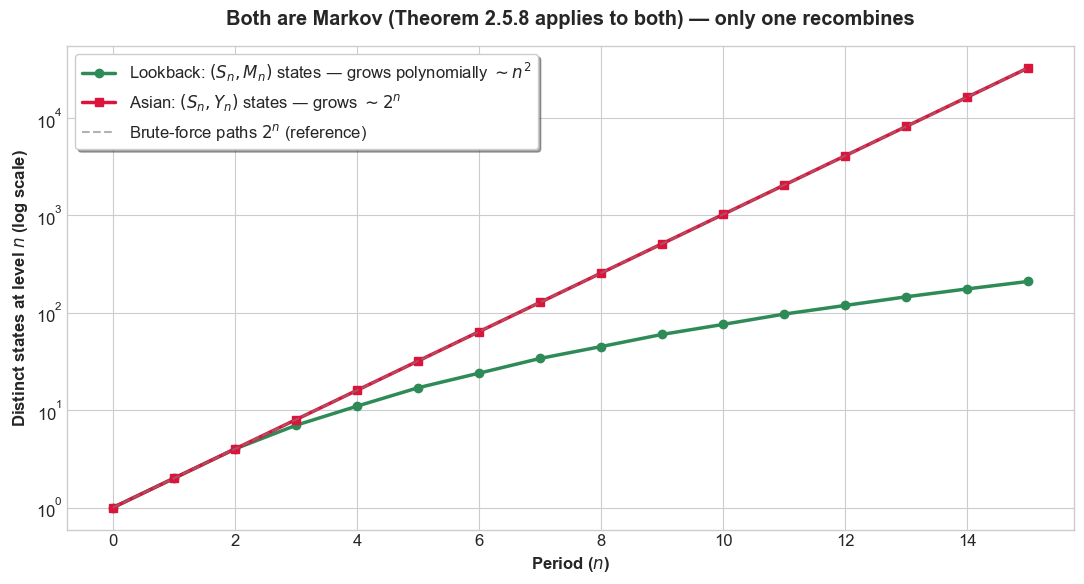


At n=15: Lookback keeps 210 states, Asian needs 32768 out of 32768 possible paths (= 2^15) -- the Asian count now genuinely reaches the brute-force bound, confirming O(2^N) rather than an artifact of round parameters.


In [12]:
s0, u, d, r = 4.0, 2.0, 0.5, 0.25
stock_model = BinomialStockModel(s0=s0, u=u, d=d, r=r)
p_tilde, _ = stock_model.risk_neutral_prob

N_check = 4
space_check = CoinTossSpace(n_periods=N_check, p=p_tilde)

process_lookback, process_asian = [], []
for n in range(N_check + 1):
    layer_lb, layer_as = {}, {}
    prefixes = [""] if n == 0 else ["".join(seq) for seq in product("HT", repeat=n)]
    for w in prefixes:
        prices = stock_model.price_path(w)
        layer_lb[w] = (prices[-1], max(prices))
        layer_as[w] = (prices[-1], sum(prices))
    process_lookback.append(layer_lb)
    process_asian.append(layer_as)

print("(S_n, M_n) is Markov (Example 2.5.6):  ", is_markov(space_check, process_lookback))
print("(S_n, Y_n) is Markov (Exercise 2.13):  ", is_markov(space_check, process_asian))

def count_states_per_level(model, payoff, n_periods):
    u_powers = [1.0] * (n_periods + 2)
    d_powers = [1.0] * (n_periods + 2)
    for i in range(1, n_periods + 2):
        u_powers[i] = u_powers[i - 1] * model.u
        d_powers[i] = d_powers[i - 1] * model.d

    def get_s(j, n_step):
        return model.s0 * u_powers[j] * d_powers[n_step - j]

    m0 = payoff.initial_aggregate(model.s0)
    states_by_level = {0: {(0, m0)}}
    for n in range(n_periods):
        next_level = set()
        for j, m in states_by_level[n]:
            s_up = get_s(j + 1, n + 1)
            next_level.add((j + 1, payoff.update_aggregate(m, s_up)))
            s_down = get_s(j, n + 1)
            next_level.add((j, payoff.update_aggregate(m, s_down)))
        states_by_level[n + 1] = next_level

    return [len(states_by_level[n]) for n in range(n_periods + 1)]

scaling_model = BinomialStockModel(s0=s0, u=1.2, d=0.8, r=0.05)

N_scale = 15
levels = list(range(N_scale + 1))
counts_lookback = count_states_per_level(scaling_model, LookbackOption(), N_scale)
counts_asian = count_states_per_level(scaling_model, AsianOption(strike=0.0, n_periods=N_scale), N_scale)
counts_brute = [2 ** n for n in levels]

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(levels, counts_lookback, 'o-', color='seagreen', linewidth=2.5,
        label=r'Lookback: $(S_n, M_n)$ states — grows polynomially $\sim n^2$')
ax.plot(levels, counts_asian, 's-', color='crimson', linewidth=2.5,
        label=r'Asian: $(S_n, Y_n)$ states — grows $\sim 2^n$')
ax.plot(levels, counts_brute, '--', color='gray', alpha=0.6, label=r'Brute-force paths $2^n$ (reference)')

ax.set_yscale('log')
ax.set_title('Both are Markov (Theorem 2.5.8 applies to both) — only one recombines', fontweight='bold', pad=15)
ax.set_xlabel('Period ($n$)', fontweight='bold')
ax.set_ylabel('Distinct states at level $n$ (log scale)', fontweight='bold')
ax.legend(loc='upper left', frameon=True, shadow=True)
plt.tight_layout()
plt.show()

print(f"\nAt n={N_scale}: Lookback keeps {counts_lookback[-1]} states, Asian needs {counts_asian[-1]} "
      f"out of {counts_brute[-1]} possible paths (= 2^{N_scale}) -- the Asian count now genuinely "
      f"reaches the brute-force bound, confirming O(2^N) rather than an artifact of round parameters.")

### 6. Put-Call Parity and the Chooser Option (Exercises 2.11–2.12)

Exercise 2.11 shows that a call, a put, and a forward on the same stock and strike are not independent: $C_n = F_n + P_n$ at every node, for every $n$ — buying a forward and a put replicates a call exactly. Exercise 2.12 builds on this to price a **chooser option**: the right to decide at time $m < N$ whether the contract becomes a call or a put (both struck at $K$, expiring at $N$). Its time-zero price collapses to a put plus an *adjusted-strike* call: $\text{Put}(K, N) + \text{Call}\!\left(\frac{K}{(1+r)^{N-m}}, m\right)$.

We verify parity across a range of strikes, then verify the chooser identity and show it dominates a plain call and a plain put at every strike — it has to, since it embeds optionality on top of both.

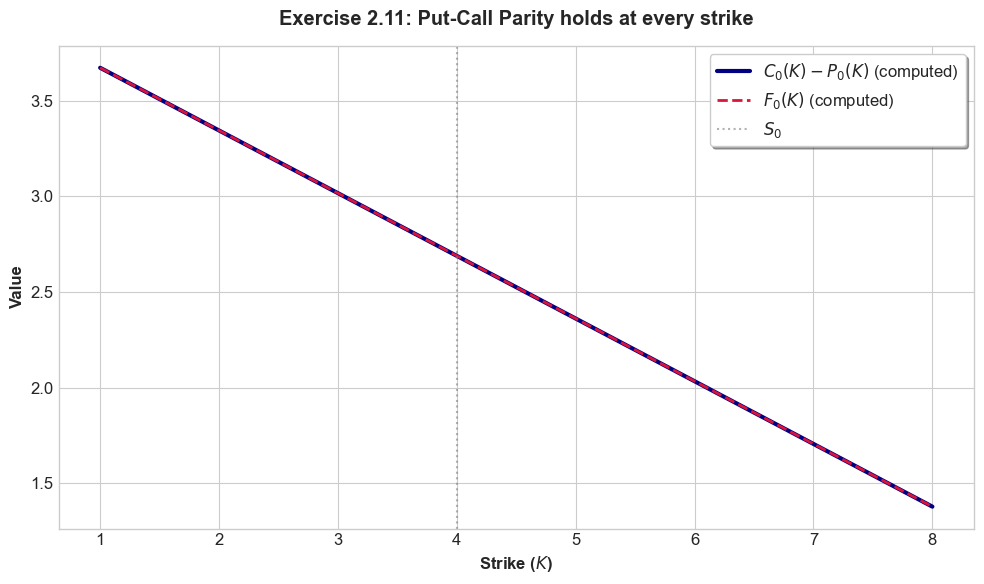

Max |C_0(K) - P_0(K) - F_0(K)| across all strikes: 1.3322676295501878e-15


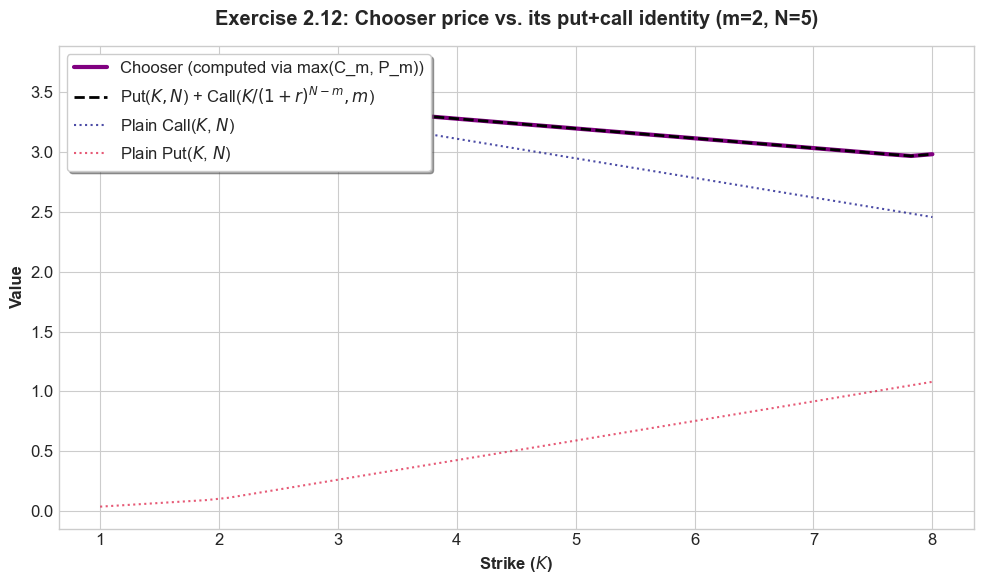

Max |Chooser - (Put + adjusted Call)| across all strikes: 8.881784197001252e-16
Chooser dominates both plain Call and plain Put at every strike: True


In [13]:
s0, u, d, r = 4.0, 2.0, 0.5, 0.25
stock_model = BinomialStockModel(s0=s0, u=u, d=d, r=r)
p_tilde, _ = stock_model.risk_neutral_prob
engine = PricingEngine()

N = 5
strikes = np.linspace(1.0, 8.0, 40)

calls = [engine.price(stock_model, EuropeanCall(strike=K), n_periods=N).v0 for K in strikes]
puts = [engine.price(stock_model, EuropeanPut(strike=K), n_periods=N).v0 for K in strikes]
forwards = [engine.price(stock_model, Forward(delivery_price=K), n_periods=N).v0 for K in strikes]
c_minus_p = [c - p for c, p in zip(calls, puts)]

fig, ax = plt.subplots()
ax.plot(strikes, c_minus_p, color='navy', linewidth=3, label=r'$C_0(K) - P_0(K)$ (computed)')
ax.plot(strikes, forwards, '--', color='crimson', linewidth=2, label=r'$F_0(K)$ (computed)')
ax.axvline(x=s0, color='gray', linestyle=':', alpha=0.6, label='$S_0$')
ax.set_title('Exercise 2.11: Put-Call Parity holds at every strike', fontweight='bold', pad=15)
ax.set_xlabel('Strike ($K$)', fontweight='bold')
ax.set_ylabel('Value', fontweight='bold')
ax.legend(loc='upper right', frameon=True, shadow=True)
plt.tight_layout()
plt.show()

print("Max |C_0(K) - P_0(K) - F_0(K)| across all strikes:", max(abs(a - b) for a, b in zip(c_minus_p, forwards)))

m = N // 2  

def price_chooser(K, N, m, stock_model, engine, p_tilde, r):
    res_call_N = engine.price(stock_model, EuropeanCall(strike=K), n_periods=N)
    res_put_N = engine.price(stock_model, EuropeanPut(strike=K), n_periods=N)

    chooser_m = {}
    for seq in product("HT", repeat=m):
        path = "".join(seq)
        chooser_m[path] = max(res_call_N.value_grid[path], res_put_N.value_grid[path])

    space_m = CoinTossSpace(n_periods=m, p=p_tilde)
    return space_m.expectation(chooser_m) / ((1 + r) ** m), res_call_N.v0, res_put_N.v0

choosers, plain_calls, plain_puts, identity_rhs = [], [], [], []
for K in strikes:
    chooser_0, call_0, put_0 = price_chooser(K, N, m, stock_model, engine, p_tilde, r)
    adjusted_strike = K / ((1 + r) ** (N - m))
    call_m_adjusted = engine.price(stock_model, EuropeanCall(strike=adjusted_strike), n_periods=m).v0

    choosers.append(chooser_0)
    plain_calls.append(call_0)
    plain_puts.append(put_0)
    identity_rhs.append(put_0 + call_m_adjusted)

fig, ax = plt.subplots()
ax.plot(strikes, choosers, color='purple', linewidth=3, label='Chooser (computed via max(C_m, P_m))')
ax.plot(strikes, identity_rhs, '--', color='black', linewidth=2, label=r'Put($K,N$) + Call($K/(1+r)^{N-m}, m$)')
ax.plot(strikes, plain_calls, ':', color='navy', alpha=0.7, label='Plain Call($K$, $N$)')
ax.plot(strikes, plain_puts, ':', color='crimson', alpha=0.7, label='Plain Put($K$, $N$)')

ax.set_title(f'Exercise 2.12: Chooser price vs. its put+call identity (m={m}, N={N})', fontweight='bold', pad=15)
ax.set_xlabel('Strike ($K$)', fontweight='bold')
ax.set_ylabel('Value', fontweight='bold')
ax.legend(loc='upper left', frameon=True, shadow=True)
plt.tight_layout()
plt.show()

print("Max |Chooser - (Put + adjusted Call)| across all strikes:",
      max(abs(a - b) for a, b in zip(choosers, identity_rhs)))
print("Chooser dominates both plain Call and plain Put at every strike:",
      all(ch >= c - 1e-9 and ch >= p - 1e-9 for ch, c, p in zip(choosers, plain_calls, plain_puts)))

## Chapter 3 - Stochastic Calculus for Finance I: State Prices - Steven E. Shreve

Chapters 1 and 2 gave two equivalent descriptions of the same arbitrage-free price: the backward-induction algorithm of Theorem 1.2.2, and the risk-neutral conditional expectation of Theorem 2.4.7. Chapter 3 adds a third description that never touches $\tilde{\mathbb{P}}$ at all — it prices everything under the *actual* probability measure $\mathbb{P}$, using the Radon-Nikodym derivative $Z$ to correct for the fact that $\mathbb{P}$ and $\tilde{\mathbb{P}}$ disagree about how likely each path is. The same machinery — $Z$, and the state price density $\zeta=Z/(1+r)^N$ — then turns out to solve a completely different problem: what an investor with a given utility function should optimally hold, a question no amount of risk-neutral pricing alone could answer.

This section extends `binomial_pricer` with two new modules:
- `state_prices.py` — the Radon-Nikodym derivative and state price density, both as static objects ($Z$, $\zeta$, Section 3.1) and as adapted processes ($Z_n$, $\zeta_n$, Section 3.2), plus the two pricing formulas built on them.
- `optimal_investment.py` — the `Utility` hierarchy (`LogUtility`, `PowerUtility`, `GoalUtility`) and the two solvers built on Theorem 3.3.6 and Exercise 3.9, both of which reuse `ReducedStateEngine` rather than introducing a new pricing engine (Section 3.3).

### 1. Change of Measure: Two Roads to the Same Price (Example 3.1.2)

Chapters 1 and 2 always priced under the risk-neutral measure $\tilde{\mathbb{P}}$ — reasonably so, since the discounted price $(1+r)^{-N}V_N$ has zero drift only under $\tilde{\mathbb{P}}$. Theorem 3.1.1 shows this was never strictly necessary: the Radon-Nikodym derivative $Z(\omega)=\tilde{\mathbb{P}}(\omega)/\mathbb{P}(\omega)$ (Eq. 3.1.1) reweights every path so that pricing works entirely under the *actual* measure $\mathbb{P}$ instead, via the state price density $\zeta(\omega)=Z(\omega)/(1+r)^N$ (Eq. 3.1.9) and the formula $V_0=\mathbb{E}[\zeta V_N]$ (Eq. 3.1.10).

We put this to the exact test Shreve does in Example 3.1.2: reprice the three-period lookback option of Example 1.2.4 — whose $V_0=1.376$ Chapter 1's `ReducedStateEngine` already reproduced — this time purely from the actual probabilities $p=2/3, q=1/3$, without the pricing formula itself ever touching $\tilde{p}=\tilde{q}=1/2$.

=== Example 3.1.2: pricing the same lookback two ways ===
V0 via risk-neutral formula (Chapter 1/2): 1.3760
V0 via state price density (Chapter 3):     1.3760
Shreve's own value:                          1.3760

✅ Both formulas agree to machine precision -- Theorem 3.1.1 holds exactly.


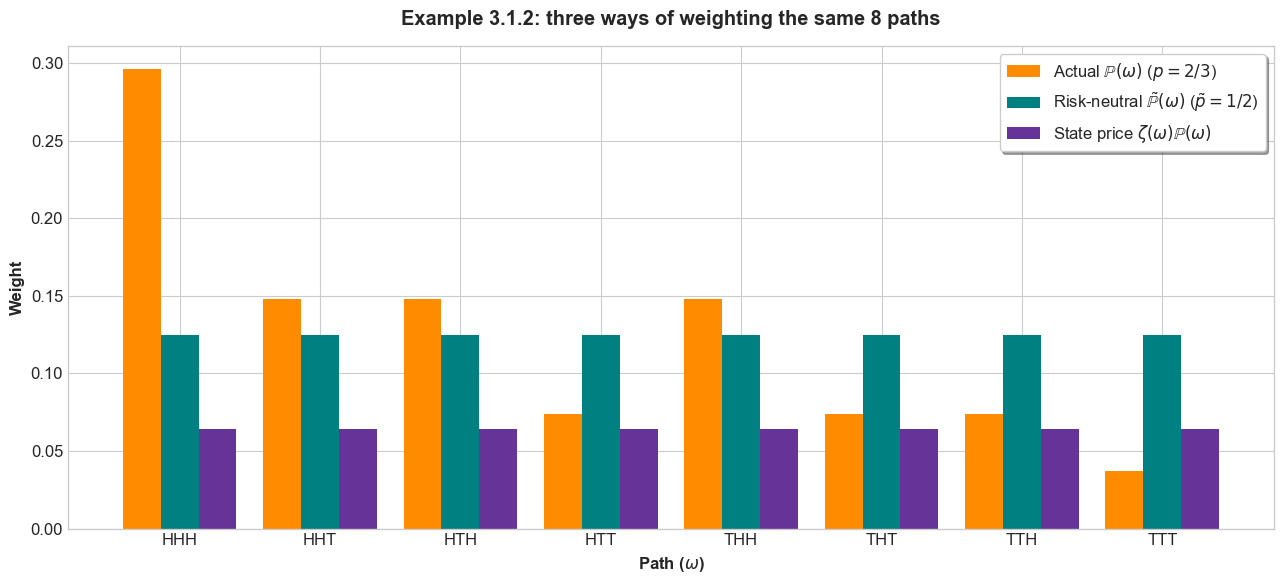


Sum of state prices (= price of a bond paying 1 for sure): 0.512
Theoretical value 1/(1+r)^N = 0.5120


In [14]:
lookback_shreve = LookbackOption()
p_actual = 2 / 3
N = 3

actual_space = CoinTossSpace(n_periods=N, p=p_actual)
p_tilde, _ = shreve_model.risk_neutral_prob
rn_space = CoinTossSpace(n_periods=N, p=p_tilde)

payoff_dict = {w: lookback_shreve.compute(shreve_model.price_path(w)) for w in actual_space.get_omega()}

z_dict = radon_nikodym_derivative(actual_space, rn_space)
zeta_dict = state_price_density(actual_space, rn_space, shreve_model.r, N, z_dict=z_dict)

v0_risk_neutral = sum(payoff_dict[w] * rn_space.probability(w) for w in rn_space.get_omega()) / (1 + shreve_model.r) ** N
v0_state_price = price_via_state_prices(payoff_dict, actual_space, zeta_dict)

print("=== Example 3.1.2: pricing the same lookback two ways ===")
print(f"V0 via risk-neutral formula (Chapter 1/2): {v0_risk_neutral:.4f}")
print(f"V0 via state price density (Chapter 3):     {v0_state_price:.4f}")
print(f"Shreve's own value:                          1.3760")
assert abs(v0_risk_neutral - v0_state_price) < 1e-9
print("\n✅ Both formulas agree to machine precision -- Theorem 3.1.1 holds exactly.")

paths = actual_space.get_omega()
p_vals = [actual_space.probability(w) for w in paths]
p_tilde_vals = [rn_space.probability(w) for w in paths]
state_prices_vals = [zeta_dict[w] * actual_space.probability(w) for w in paths]

x = np.arange(len(paths))
width = 0.27

fig, ax = plt.subplots(figsize=(13, 6))
ax.bar(x - width, p_vals, width, label=r'Actual $\mathbb{P}(\omega)$ ($p=2/3$)', color='darkorange')
ax.bar(x, p_tilde_vals, width, label=r'Risk-neutral $\tilde{\mathbb{P}}(\omega)$ ($\tilde p=1/2$)', color='teal')
ax.bar(x + width, state_prices_vals, width, label=r'State price $\zeta(\omega)\mathbb{P}(\omega)$', color='rebeccapurple')

ax.set_xticks(x)
ax.set_xticklabels(paths)
ax.set_title('Example 3.1.2: three ways of weighting the same 8 paths', fontweight='bold', pad=15)
ax.set_xlabel(r'Path ($\omega$)', fontweight='bold')
ax.set_ylabel('Weight', fontweight='bold')
ax.legend(loc='upper right', frameon=True, shadow=True)

plt.tight_layout()
plt.show()

print("\nSum of state prices (= price of a bond paying 1 for sure):", sum(state_prices_vals))
print(f"Theoretical value 1/(1+r)^N = {1 / (1 + shreve_model.r) ** N:.4f}")

### 2. The Process $Z_n$: A Martingale in Disguise (Example 3.2.3)

$Z$ prices the whole $N$-period path at once; Definition 3.2.4 makes it dynamic by setting $Z_n=\mathbb{E}_n[Z]$, an adapted process that starts at $Z_0=1$ and ends at $Z_N=Z$. Theorem 3.2.1 proves $Z_n$ is a martingale under the *actual* measure $\mathbb{P}$ — the same iterated-conditioning argument Chapter 2 used for the discounted stock price, just applied to a different random variable. We rebuild Shreve's own $Z_n$ tree from Example 3.2.3 for the same lookback model, and hand it straight to `is_martingale` — the very validator Chapter 2 built for Theorems 2.4.4 and 2.4.5.

=== Example 3.2.3: the Z_n tree ===
Z_0 = 1.0000   (must equal 1, by Theorem 3.1.1(ii))
Z_1(H) = 0.7500   Z_1(T) = 1.5000
Z_2(HH) = 0.5625  Z_2(HT) = 1.1250  Z_2(TH) = 1.1250  Z_2(TT) = 2.2500

Z_n is a martingale under the actual measure P: True


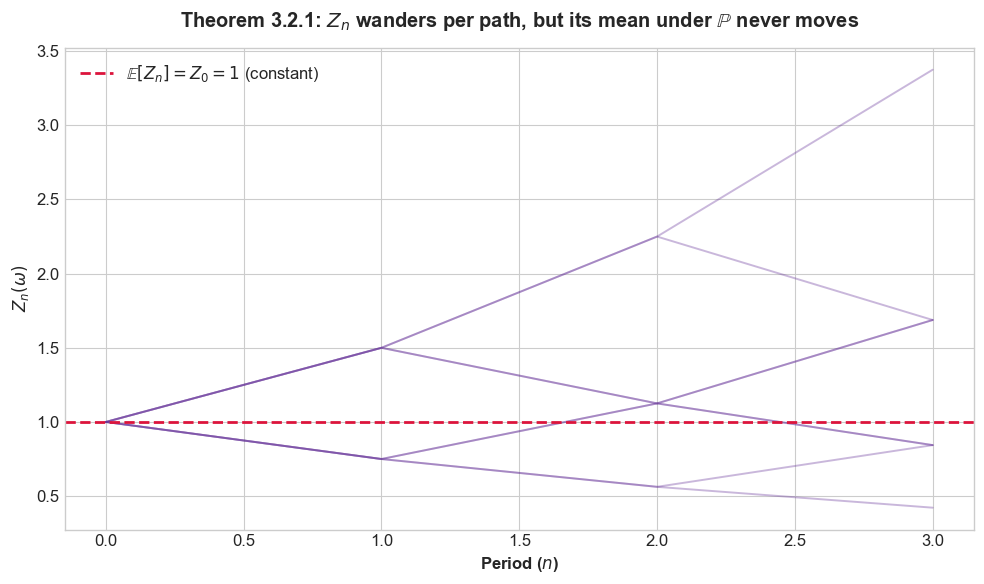

In [15]:
z_process = radon_nikodym_process(actual_space, rn_space)

print("=== Example 3.2.3: the Z_n tree ===")
print(f"Z_0 = {z_process[0]['']:.4f}   (must equal 1, by Theorem 3.1.1(ii))")
print(f"Z_1(H) = {z_process[1]['H']:.4f}   Z_1(T) = {z_process[1]['T']:.4f}")
print(f"Z_2(HH) = {z_process[2]['HH']:.4f}  Z_2(HT) = {z_process[2]['HT']:.4f}  "
      f"Z_2(TH) = {z_process[2]['TH']:.4f}  Z_2(TT) = {z_process[2]['TT']:.4f}")

print("\nZ_n is a martingale under the actual measure P:", is_martingale(actual_space, z_process))

full_paths = actual_space.get_omega()
fig, ax = plt.subplots()
for path in full_paths:
    y = [z_process[n][path[:n]] for n in range(N + 1)]
    ax.plot(range(N + 1), y, color='rebeccapurple', alpha=0.35, linewidth=1.4)
ax.axhline(y=1.0, color='crimson', linestyle='--', linewidth=2, label=r'$\mathbb{E}[Z_n] = Z_0 = 1$ (constant)')
ax.set_title(r'Theorem 3.2.1: $Z_n$ wanders per path, but its mean under $\mathbb{P}$ never moves',
             fontweight='bold', pad=15)
ax.set_xlabel('Period ($n$)', fontweight='bold')
ax.set_ylabel(r'$Z_n(\omega)$', fontweight='bold')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

### 3. Same Price Today, Different Price Tomorrow (Exercise 3.4(iii)-(iv))

Combining $Z_n$ with discounting gives the state price density process $\zeta_n=Z_n/(1+r)^n$ (Eq. 3.2.7), and Theorem 3.2.7 restates risk-neutral pricing entirely in these terms: $V_n=\tilde{\mathbb{E}}_n[\cdot]=\frac{1}{\zeta_n}\mathbb{E}_n[\zeta_N V_N]$ (Eq. 3.2.6). Exercise 3.4(iii)-(iv) uses this to make a subtle point about the Asian option of Exercise 1.8: the paths $HT$ and $TH$ reach the *same* stock price $S_2=4$, yet — because their accumulated sums $Y_2=16$ and $Y_2=10$ differ — the option is not worth the same. We compute $V_2(HT)$ and $V_2(TH)$ via `price_step_via_state_density_process` and cross-check them against `ReducedStateEngine`'s own `value_grid`, which already carries $Y_n$ as part of its state key.

=== Exercise 3.4(iii)-(iv): the Asian option at n=2 ===
S_2(HT) = S_2(TH) = 4.00   (same stock price!)
V_2(HT) via state price density: 1.0000   via ReducedStateEngine: 1.0000
V_2(TH) via state price density: 0.2000   via ReducedStateEngine: 0.2000

✅ Both computation routes agree exactly.
V_2(HT) != V_2(TH): True  -- same price today, different accumulated history.


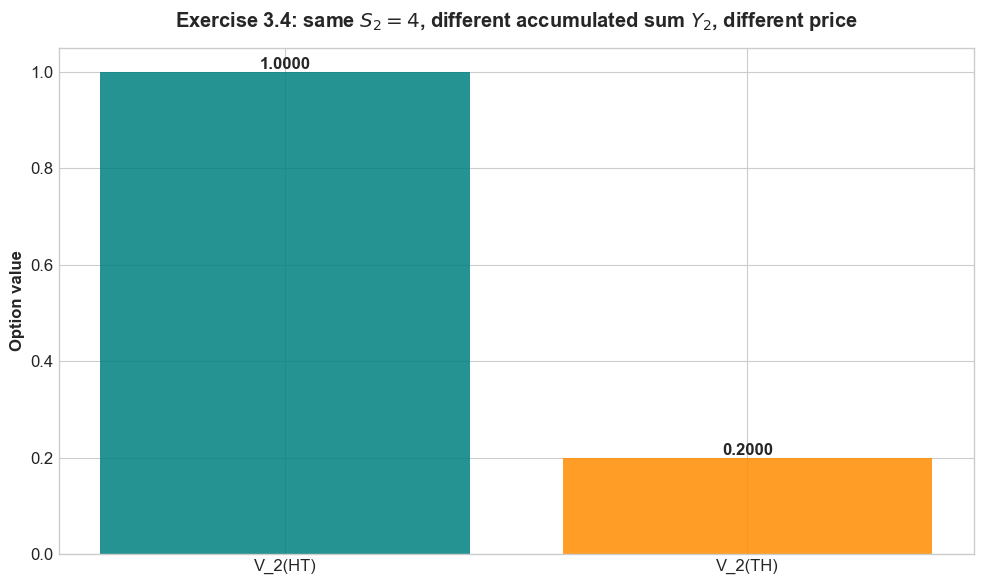

In [16]:
asian_shreve = AsianOption(strike=4.0, n_periods=N)
payoff_dict_asian = {w: asian_shreve.compute(shreve_model.price_path(w)) for w in actual_space.get_omega()}

zeta_process = state_price_density_process(actual_space, rn_space, shreve_model.r)
v2 = price_step_via_state_density_process(payoff_dict_asian, actual_space, zeta_process, 2)

reduced_result = ReducedStateEngine().price(shreve_model, asian_shreve, n_periods=N)

print("=== Exercise 3.4(iii)-(iv): the Asian option at n=2 ===")
print(f"S_2(HT) = S_2(TH) = {shreve_model.price_path('HT')[-1]:.2f}   (same stock price!)")
print(f"V_2(HT) via state price density: {v2['HT']:.4f}   via ReducedStateEngine: {reduced_result.value_grid[(2, 4.0, 16.0)]:.4f}")
print(f"V_2(TH) via state price density: {v2['TH']:.4f}   via ReducedStateEngine: {reduced_result.value_grid[(2, 4.0, 10.0)]:.4f}")

assert abs(v2['HT'] - reduced_result.value_grid[(2, 4.0, 16.0)]) < 1e-9
assert abs(v2['TH'] - reduced_result.value_grid[(2, 4.0, 10.0)]) < 1e-9
print("\n✅ Both computation routes agree exactly.")
print(f"V_2(HT) != V_2(TH): {not np.isclose(v2['HT'], v2['TH'])}  -- same price today, different accumulated history.")

fig, ax = plt.subplots()
labels = ['V_2(HT)', 'V_2(TH)']
values = [v2['HT'], v2['TH']]
colors = ['teal', 'darkorange']
ax.bar(labels, values, color=colors, alpha=0.85)
for i, v in enumerate(values):
    ax.annotate(f"{v:.4f}", (i, v), ha='center', va='bottom', fontweight='bold')
ax.set_title(r'Exercise 3.4: same $S_2=4$, different accumulated sum $Y_2$, different price', fontweight='bold', pad=15)
ax.set_ylabel('Option value', fontweight='bold')
plt.tight_layout()
plt.show()

### 4. Optimal Investment Under Log Utility (Example 3.3.2)

Section 3.3 turns the state price density into something new: not a pricing multiplier for a *given* derivative, but the constraint multiplier in a portfolio-choice problem. Theorem 3.3.6 shows that an investor with utility $U$ and initial wealth $X_0$ should hold $X_N=I(\lambda Z/(1+r)^N)$ (Eq. 3.3.25), where $I=(U')^{-1}$ and $\lambda$ solves the budget equation (Eq. 3.3.26) — and that the resulting portfolio is then just an ordinary derivative security, replicable by the *same* backward-induction algorithm (Theorem 1.2.2) Chapter 1 already built. `solve_optimal_investment` implements exactly this two-step recipe, reusing `ReducedStateEngine` rather than any new pricing machinery. We reproduce Shreve's own two-period, log-utility example by hand.

=== Example 3.3.2: Optimal investment under log utility ===
Delta_0    = 0.5556   (Shreve: 5/9 = 0.5556)
Delta_1(H) = 0.4630   (Shreve: 25/54 = 0.4630)
Delta_1(T) = 0.9259   (Shreve: 25/27 = 0.9259)
X_1(H)     = 6.6667   (Shreve: 20/3 = 6.6667)
X_1(T)     = 3.3333   (Shreve: 10/3 = 3.3333)
X_2(HH)=11.1111 X_2(HT)=5.5556 X_2(TH)=5.5556 X_2(TT)=2.7778

✅ The replicating portfolio starts exactly at X_0 = 4, as it must.


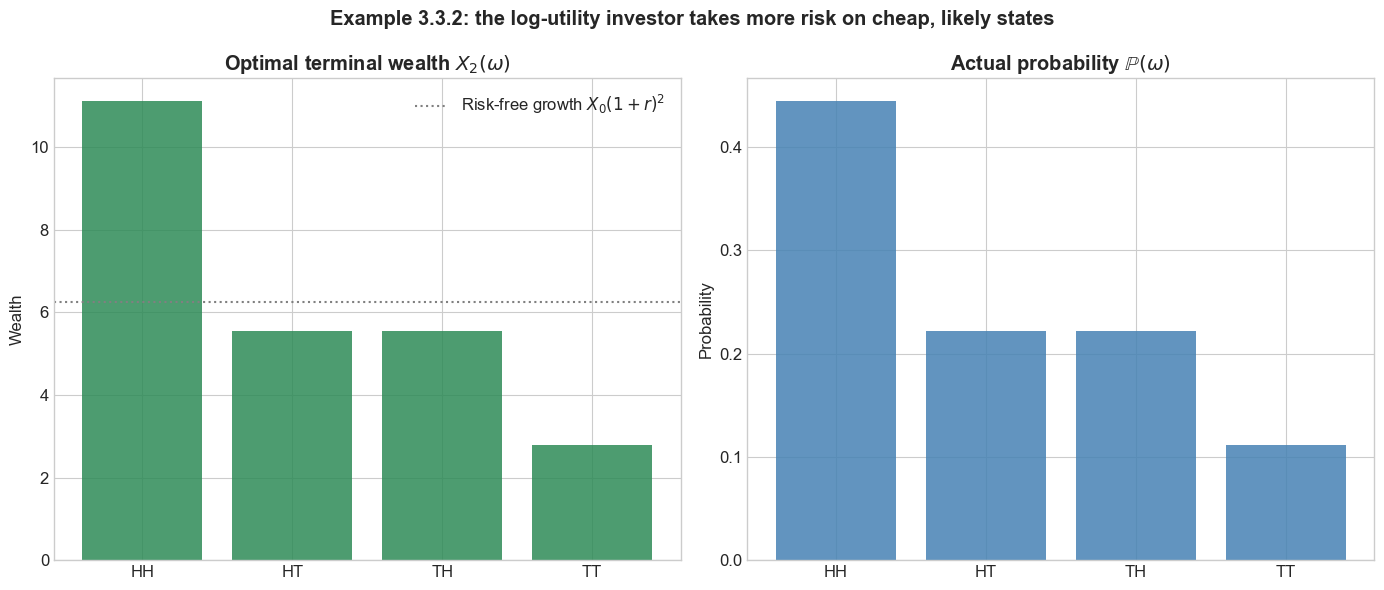

In [17]:
example_332_model = BinomialStockModel(s0=4.0, u=2.0, d=0.5, r=0.25)
actual_space_332 = CoinTossSpace(n_periods=2, p=2 / 3)

log_utility = LogUtility()
x_n_dict, opt_result = solve_optimal_investment(example_332_model, actual_space_332, log_utility, x0=4.0)

print("=== Example 3.3.2: Optimal investment under log utility ===")
print(f"Delta_0    = {opt_result.delta_grid[(0, 4.0)]:.4f}   (Shreve: 5/9 = {5 / 9:.4f})")
print(f"Delta_1(H) = {opt_result.delta_grid[(1, 8.0)]:.4f}   (Shreve: 25/54 = {25 / 54:.4f})")
print(f"Delta_1(T) = {opt_result.delta_grid[(1, 2.0)]:.4f}   (Shreve: 25/27 = {25 / 27:.4f})")
print(f"X_1(H)     = {opt_result.value_grid[(1, 8.0)]:.4f}   (Shreve: 20/3 = {20 / 3:.4f})")
print(f"X_1(T)     = {opt_result.value_grid[(1, 2.0)]:.4f}   (Shreve: 10/3 = {10 / 3:.4f})")
print(f"X_2(HH)={x_n_dict['HH']:.4f} X_2(HT)={x_n_dict['HT']:.4f} X_2(TH)={x_n_dict['TH']:.4f} X_2(TT)={x_n_dict['TT']:.4f}")

assert abs(opt_result.v0 - 4.0) < 1e-9
print("\n✅ The replicating portfolio starts exactly at X_0 = 4, as it must.")

paths_332 = ['HH', 'HT', 'TH', 'TT']
wealth_332 = [x_n_dict[w] for w in paths_332]
probs_332 = [actual_space_332.probability(w) for w in paths_332]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
ax1.bar(paths_332, wealth_332, color='seagreen', alpha=0.85)
ax1.axhline(y=example_332_model.s0 * ((1 + example_332_model.r) ** 2), color='gray', linestyle=':',
            label=r'Risk-free growth $X_0(1+r)^2$')
ax1.set_title(r'Optimal terminal wealth $X_2(\omega)$', fontweight='bold')
ax1.set_ylabel('Wealth')
ax1.legend()

ax2.bar(paths_332, probs_332, color='steelblue', alpha=0.85)
ax2.set_title(r'Actual probability $\mathbb{P}(\omega)$', fontweight='bold')
ax2.set_ylabel('Probability')

plt.suptitle('Example 3.3.2: the log-utility investor takes more risk on cheap, likely states', fontweight='bold')
plt.tight_layout()
plt.show()

### 5. Risk Aversion Reshapes the Bet (Exercises 3.6-3.7)

Exercises 3.6 and 3.7 give closed-form solutions for two members of the HARA family: logarithmic utility ($X_n=X_0/\zeta_n$) and power utility $U_p(x)=\frac1p x^p$ ($X_N=X_0(1+r)^N Z^{1/(p-1)}/\mathbb{E}[Z^{p/(p-1)}]$). Both are implemented as closed forms in `LogUtility`/`PowerUtility`, bypassing the numerical root-finding Theorem 3.3.6 needs in general — but they must still be *consistent* with that general recipe. Below we vary $p$ across a spectrum of risk aversion (log utility sits at the $p\to0$ limit) and watch how the optimal terminal wealth $X_N(\omega)$ spreads out across cheap and expensive states; then we disable `PowerUtility`'s closed form for one $p$ and confirm `brentq` finds the identical answer numerically.

Power (p=-5, very risk averse): wealth range = [9.970, 17.072]
Power (p=-1): wealth range = [6.369, 31.976]
Log (p=0): wealth range = [2.843, 71.680]
Power (p=0.5, less risk averse): wealth range = [0.355, 225.549]


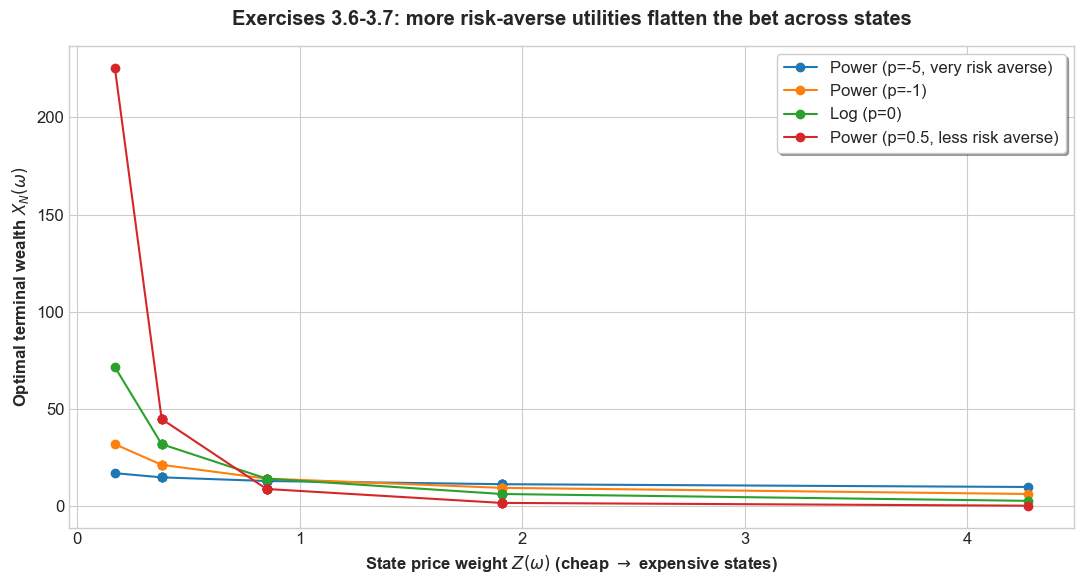


Max |closed-form - brentq numeric| across all paths: 1.82e-10
✅ Exercise 3.7's closed form and the general Theorem 3.3.6 solver agree to numerical precision.


In [18]:
n_periods_hara = 4
model_hara = BinomialStockModel(s0=4.0, u=1.6, d=0.75, r=0.05)
actual_space_hara = CoinTossSpace(n_periods=n_periods_hara, p=0.55)
x0_hara = 10.0

utilities = {
    'Power (p=-5, very risk averse)': PowerUtility(p=-5.0),
    'Power (p=-1)': PowerUtility(p=-1.0),
    'Log (p=0)': LogUtility(),
    'Power (p=0.5, less risk averse)': PowerUtility(p=0.5),
}

rn_space_hara = CoinTossSpace(n_periods=n_periods_hara, p=model_hara.risk_neutral_prob[0])
z_dict_hara = radon_nikodym_derivative(actual_space_hara, rn_space_hara)

fig, ax = plt.subplots(figsize=(11, 6))
paths_hara = sorted(actual_space_hara.get_omega(), key=lambda w: z_dict_hara[w])
z_sorted = [z_dict_hara[w] for w in paths_hara]

for label, utility in utilities.items():
    x_n_dict_h, _ = solve_optimal_investment(model_hara, actual_space_hara, utility, x0_hara)
    wealth_sorted = [x_n_dict_h[w] for w in paths_hara]
    ax.plot(z_sorted, wealth_sorted, marker='o', label=label)
    print(f"{label}: wealth range = [{min(wealth_sorted):.3f}, {max(wealth_sorted):.3f}]")

ax.set_xlabel(r'State price weight $Z(\omega)$ (cheap $\to$ expensive states)', fontweight='bold')
ax.set_ylabel(r'Optimal terminal wealth $X_N(\omega)$', fontweight='bold')
ax.set_title('Exercises 3.6-3.7: more risk-averse utilities flatten the bet across states',
             fontweight='bold', pad=15)
ax.legend(loc='upper right', frameon=True, shadow=True)
plt.tight_layout()
plt.show()


class NumericPowerUtility(PowerUtility):
    def get_closed_form_lambda(self, x0, actual_space, z_dict, r):
        return None


closed = PowerUtility(p=-2.0)
numeric = NumericPowerUtility(p=-2.0)
x_closed, _ = solve_optimal_investment(model_hara, actual_space_hara, closed, x0_hara)
x_numeric, _ = solve_optimal_investment(model_hara, actual_space_hara, numeric, x0_hara)
max_diff = max(abs(x_closed[w] - x_numeric[w]) for w in actual_space_hara.get_omega())
print(f"\nMax |closed-form - brentq numeric| across all paths: {max_diff:.2e}")
print("✅ Exercise 3.7's closed form and the general Theorem 3.3.6 solver agree to numerical precision.")

### 6. Betting Everything on Reaching the Goal (Exercise 3.9, Kulldorff-Heath)

Not every utility is smooth. Exercise 3.9 asks for the portfolio that maximizes $\mathbb{P}(X_N\ge\gamma)$ for a fixed goal $\gamma$ — equivalent to an *indicator* utility, $U(x)=\mathbb{1}\{x\ge\gamma\}$, which has no derivative to invert. The exercise's own argument (mirroring Exercise 3.8's Legendre-transform trick) shows the optimal rule is a pure threshold: rank every path by its state price density $\zeta_m$ ascending, and fund the cheapest ones with the full goal amount $\gamma$ until the budget $X_0$ runs out (Eq. 3.6.5). This is exactly what `solve_goal_probability_maximization` does — a dedicated solver, since `Utility.inverse_marginal`'s single-value interface has nothing to invert here. We visualize the cutoff directly: which paths get funded, and how the cumulative cost climbs until it hits $X_0$.

=== Exercise 3.9: maximizing the probability of reaching the goal ===
Goal gamma = 20.0, initial wealth X_0 = 8.0
Number of paths funded (out of 16): 7
Resulting P(X_N >= gamma): 0.5135


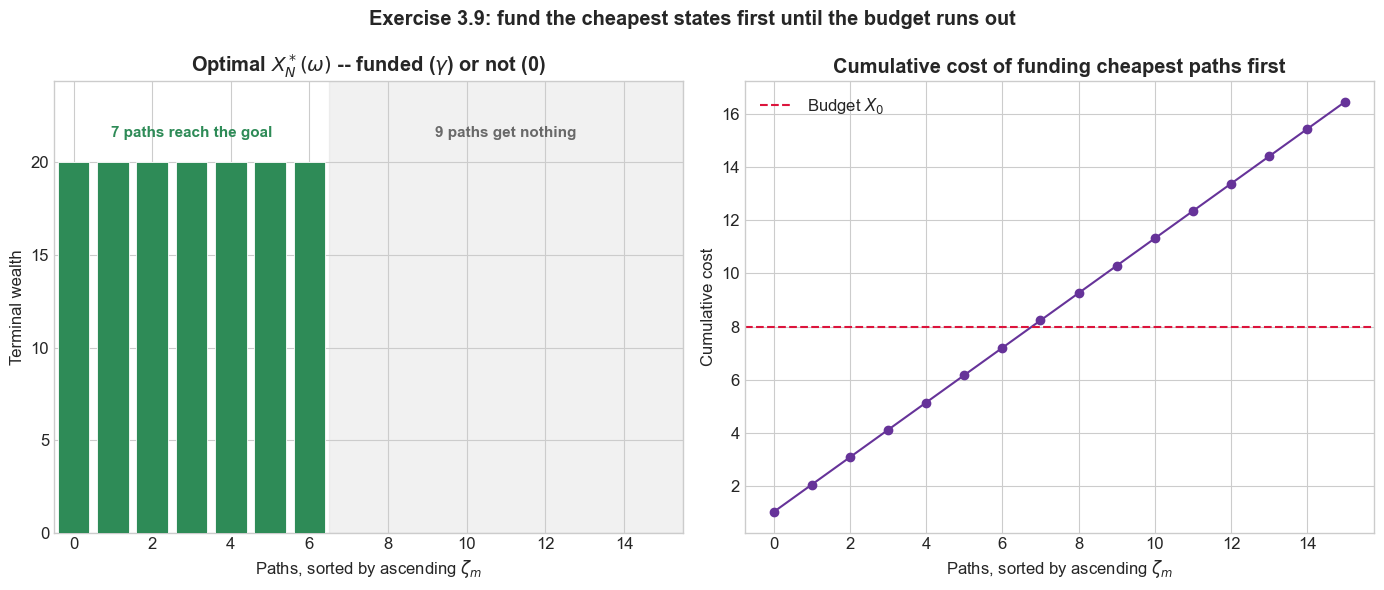

In [19]:
n_periods_goal = 4
actual_space_goal = CoinTossSpace(n_periods=n_periods_goal, p=0.55)
rn_space_goal = CoinTossSpace(n_periods=n_periods_goal, p=0.5)
r_goal = 0.05
gamma_goal = 20.0
x0_goal = 8.0

zeta_goal = state_price_density(actual_space_goal, rn_space_goal, r_goal, n_periods_goal)
x_n_goal = solve_goal_probability_maximization(actual_space_goal, rn_space_goal, r_goal, x0_goal, gamma_goal)

paths_goal = sorted(actual_space_goal.get_omega(), key=lambda w: zeta_goal[w])
funded = [x_n_goal[w] for w in paths_goal]
cum_cost = np.cumsum([gamma_goal * zeta_goal[w] * actual_space_goal.probability(w) for w in paths_goal])

n_funded = sum(1 for v in funded if v > 0)
prob_success = sum(actual_space_goal.probability(w) for w in paths_goal if x_n_goal[w] > 0)

print("=== Exercise 3.9: maximizing the probability of reaching the goal ===")
print(f"Goal gamma = {gamma_goal}, initial wealth X_0 = {x0_goal}")
print(f"Number of paths funded (out of {2 ** n_periods_goal}): {n_funded}")
print(f"Resulting P(X_N >= gamma): {prob_success:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

colors = ['seagreen' if v > 0 else 'lightgray' for v in funded]
ax1.axvspan(n_funded - 0.5, len(paths_goal) - 0.5, color='lightgray', alpha=0.3, zorder=0)
ax1.bar(range(len(paths_goal)), funded, color=colors, zorder=3, edgecolor='white', linewidth=0.6)

ax1.text(n_funded / 2 - 0.5, gamma_goal * 1.06, f'{n_funded} paths reach the goal',
         ha='center', va='bottom', fontsize=11, fontweight='bold', color='seagreen')
ax1.text(n_funded + (len(paths_goal) - n_funded) / 2 - 0.5, gamma_goal * 1.06,
         f'{len(paths_goal) - n_funded} paths get nothing',
         ha='center', va='bottom', fontsize=11, fontweight='bold', color='dimgray')

ax1.set_xlim(-0.5, len(paths_goal) - 0.5)
ax1.set_ylim(0, gamma_goal * 1.22)
ax1.set_title(r'Optimal $X_N^*(\omega)$ -- funded ($\gamma$) or not (0)', fontweight='bold')
ax1.set_xlabel(r'Paths, sorted by ascending $\zeta_m$')
ax1.set_ylabel('Terminal wealth')

ax2.plot(range(len(paths_goal)), cum_cost, marker='o', color='rebeccapurple')
ax2.axhline(y=x0_goal, color='crimson', linestyle='--', label=r'Budget $X_0$')
ax2.set_title('Cumulative cost of funding cheapest paths first', fontweight='bold')
ax2.set_xlabel(r'Paths, sorted by ascending $\zeta_m$')
ax2.set_ylabel('Cumulative cost')
ax2.legend()

plt.suptitle('Exercise 3.9: fund the cheapest states first until the budget runs out', fontweight='bold')
plt.tight_layout()
plt.show()

## Chapter 4 - Stochastic Calculus for Finance I: American Derivative Securities - Steven E. Shreve

Chapters 1 through 3 priced European derivatives — contracts whose payoff is collected only at expiration. Chapter 4 adds the possibility of early exercise: at each node, the holder chooses between collecting the intrinsic value immediately or continuing to hold the contract, and the price is the larger of the two. Structurally this changes almost nothing about the engine we already built — `AmericanEngine` reuses the exact same state-indexed backward induction as `ReducedStateEngine`, just replacing the plain risk-neutral average with a `max` against the payoff's own `terminal_value`, evaluated at every node instead of only at $n=N$. What early exercise does add is genuinely new: a nonnegative *consumption process*, tracking how much the hedge can "give away" at each node without breaking the replication, and — starting in Section 4.3 — the first new probabilistic object of the whole project, the *stopping time*.

### 1. Validating AmericanEngine Against Shreve's Own Example (Example 4.2.1)

Before exploring the American algorithm with generic parameters, we ground `AmericanEngine` in the exact numerical example Shreve works through by hand in Section 4.2: $S_0=4$, $u=2$, $d=0.5$, $r=0.25$, over two periods, an American put struck at $5$. The book derives $V_0=1.36$ node by node, including the one place where early exercise is strictly optimal ($v_1(2)=3$, the tail node) and the exact \$1 of consumption that follows from it. Reproducing all of this with our own `AmericanEngine` — value grid, Delta, and consumption grid together — is a direct check that the engine faithfully implements the early-exercise algorithm of Theorem 4.2.2, not just a plausible-looking price.

In [20]:
american_model = BinomialStockModel(s0=4.0, u=2.0, d=0.5, r=0.25)
american_put = EuropeanPut(strike=5.0)

american_engine = AmericanEngine()
american_result = american_engine.price(model=american_model, payoff=american_put, n_periods=2)

print("=== Reproducing Shreve, Example 4.2.1 (Two-Period American Put) ===")
print(f"v2(16)  computed : {american_result.value_grid[(2, 16.0)]:.4f}   Shreve: 0.0000")
print(f"v2(4)   computed : {american_result.value_grid[(2, 4.0)]:.4f}   Shreve: 1.0000")
print(f"v2(1)   computed : {american_result.value_grid[(2, 1.0)]:.4f}   Shreve: 4.0000")
print(f"v1(8)   computed : {american_result.value_grid[(1, 8.0)]:.4f}   Shreve: 0.4000")
print(f"v1(2)   computed : {american_result.value_grid[(1, 2.0)]:.4f}   Shreve: 3.0000  (early exercise optimal)")
print(f"v0(4)   computed : {american_result.value_grid[(0, 4.0)]:.4f}   Shreve: 1.3600")
print(f"Delta0  computed : {american_result.delta0:.4f}   Shreve: -0.4333")

assert abs(american_result.v0 - 1.36) < 1e-9, "Mismatch against Shreve's own worked example!"
print("\n✅ Engine output matches the book exactly.")

print("\n=== Consumption at the tail node (n=1, S=2) ===")
consumption_tail = american_result.consumption_grid[(1, 2.0)]
print(f"C_1(T) computed : {consumption_tail:.4f}   Shreve: 1.0000")
assert abs(consumption_tail - 1.0) < 1e-9
print("✅ The hedger consumes exactly $1 at the tail node, exactly as the book describes.")

=== Reproducing Shreve, Example 4.2.1 (Two-Period American Put) ===
v2(16)  computed : 0.0000   Shreve: 0.0000
v2(4)   computed : 1.0000   Shreve: 1.0000
v2(1)   computed : 4.0000   Shreve: 4.0000
v1(8)   computed : 0.4000   Shreve: 0.4000
v1(2)   computed : 3.0000   Shreve: 3.0000  (early exercise optimal)
v0(4)   computed : 1.3600   Shreve: 1.3600
Delta0  computed : -0.4333   Shreve: -0.4333

✅ Engine output matches the book exactly.

=== Consumption at the tail node (n=1, S=2) ===
C_1(T) computed : 1.0000   Shreve: 1.0000
✅ The hedger consumes exactly $1 at the tail node, exactly as the book describes.


### 2. Early Exercise Reflected in the Consumption Process

The two numbers we just reproduced — $v_1(8)=0.40$ (no consumption) and $v_1(2)=3$ (consumption of \$1) — are really two different answers to the same question: at each node, does the risk-neutral continuation value already exceed the intrinsic value on its own, or does the hedger's portfolio have to give something up to stay exactly self-financing? Plotting `consumption_grid` directly over the recombining tree makes this distinction visual: green nodes are ones where early exercise is strictly better than continuing (consumption $>0$); gray nodes are ones where the position is exactly self-financing with no withdrawal.

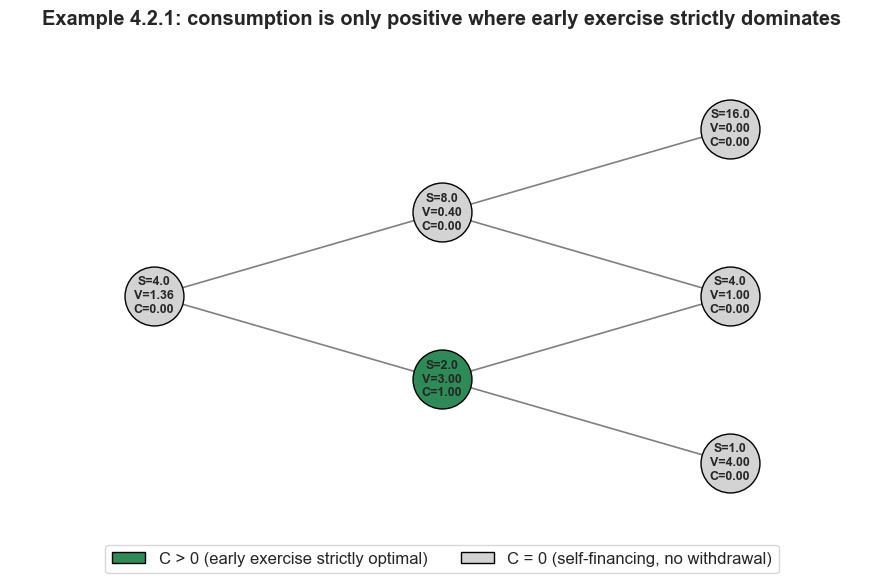

Nodes with strictly positive consumption: [(1, 2.0)]


In [21]:
def tree_positions(n_periods):
    """(n, j) -> (x, y) for a standard recombining binomial tree, j = number of up-moves."""
    return {(n, j): (n, 2 * j - n) for n in range(n_periods + 1) for j in range(n + 1)}

def node_price(model, n, j):
    return model.s0 * (model.u ** j) * (model.d ** (n - j))

n_periods = 2
positions = tree_positions(n_periods)

fig, ax = plt.subplots(figsize=(9, 6))

for n in range(n_periods):
    for j in range(n + 1):
        x0, y0 = positions[(n, j)]
        x_up, y_up = positions[(n + 1, j + 1)]
        x_down, y_down = positions[(n + 1, j)]
        ax.plot([x0, x_up], [y0, y_up], color='gray', linewidth=1.2, zorder=1)
        ax.plot([x0, x_down], [y0, y_down], color='gray', linewidth=1.2, zorder=1)

consuming_nodes = []
for n in range(n_periods + 1):
    for j in range(n + 1):
        s = node_price(american_model, n, j)
        x, y = positions[(n, j)]
        consumption = american_result.consumption_grid.get((n, s), 0.0)
        value = american_result.value_grid[(n, s)]
        is_consuming = consumption > 1e-9
        if is_consuming:
            consuming_nodes.append((n, round(s, 2)))
        color = 'seagreen' if is_consuming else 'lightgray'
        ax.scatter(x, y, s=1800, color=color, edgecolor='black', zorder=2)
        ax.annotate(f"S={s:.1f}\nV={value:.2f}\nC={consumption:.2f}", (x, y),
                    ha='center', va='center', fontsize=9, fontweight='bold', zorder=3)

ax.set_xlim(-0.5, n_periods + 0.5)
ax.set_ylim(-n_periods - 1, n_periods + 1)
ax.axis('off')
ax.set_title('Example 4.2.1: consumption is only positive where early exercise strictly dominates',
             fontweight='bold', pad=15)

legend_elements = [
    Patch(facecolor='seagreen', edgecolor='black', label='C > 0 (early exercise strictly optimal)'),
    Patch(facecolor='lightgray', edgecolor='black', label='C = 0 (self-financing, no withdrawal)'),
]
ax.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 0.02), ncol=2, frameon=True)

plt.tight_layout()
plt.show()

print("Nodes with strictly positive consumption:", consuming_nodes)

### 3. The Discounted American Price Is a Supermartingale — Until You Stop It Optimally

Section 4.3 introduces the first genuinely new probabilistic object of the project: the stopping time. We put it to work on the exact two objects the book itself uses to illustrate Theorem 4.3.2 — the discounted stock price $M_n=(1+r)^{-n}S_n$, which Chapter 2 already proved is a martingale, and the discounted American put price $Y_n=(1+r)^{-n}v_n(S_n)$ from Section 1, which Theorem 4.4.2 guarantees is only a *supermartingale*. We stop $Y_n$ at the valid exercise rule $\tau$ of Eq. (4.3.1) and watch the supermartingale become a martingale; we stop $M_n$ at the "insider" rule $\rho$ of Eq. (4.3.2) and watch a genuine martingale get destroyed instead.

=== M_n: discounted stock price ===
M_0 = 4.0000
M_1(H) = 6.4000   M_1(T) = 1.6000
M_2(HH) = 10.2400  M_2(HT) = 2.5600  M_2(TH) = 2.5600  M_2(TT) = 0.6400
Is M_n a martingale under P̃?  True

=== Y_n: discounted American put price ===
Y_0 = 1.3600
Y_1(H) = 0.3200   Y_1(T) = 2.4000
Y_2(HH) = 0.0000  Y_2(HT) = 0.6400  Y_2(TH) = 0.6400  Y_2(TT) = 2.5600
Is Y_n a supermartingale under P̃? True
Is Y_n a martingale under P̃?      False

tau is a valid stopping time: True
rho is a valid stopping time: False

Stopping Y_n (a supermartingale) at the valid tau makes it a martingale: True
Stopping M_n (a martingale) at the non-stopping rho destroys the martingale property: False


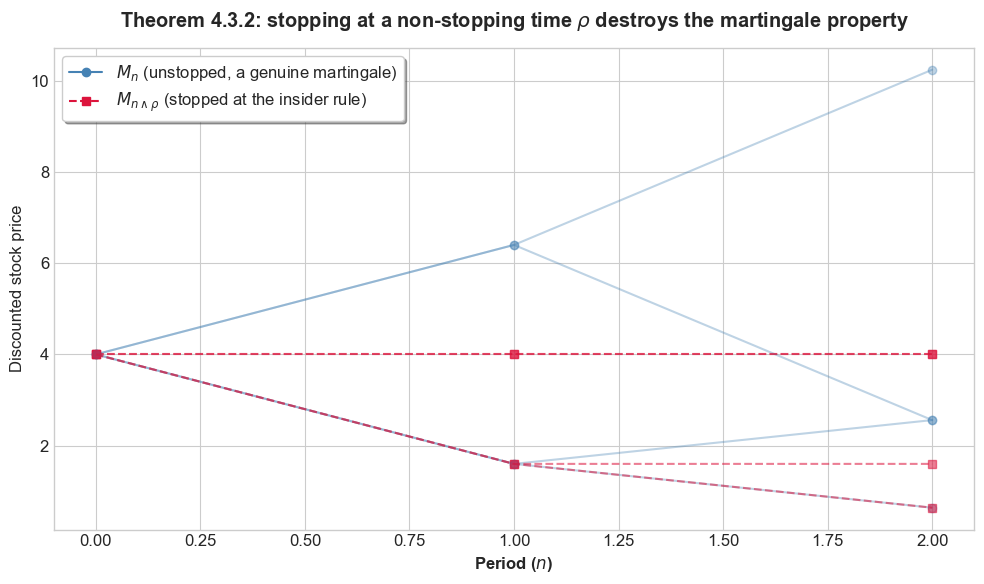

In [22]:
p_tilde, q_tilde = american_model.risk_neutral_prob
space = CoinTossSpace(n_periods=2, p=p_tilde)

M = []
for n in range(3):
    level = {}
    prefixes = [""] if n == 0 else ["".join(seq) for seq in product("HT", repeat=n)]
    for w in prefixes:
        s_n = american_model.price_path(w)[-1]
        level[w] = ((1 / (1 + american_model.r)) ** n) * s_n
    M.append(level)

Y = []
for n in range(3):
    level = {}
    prefixes = [""] if n == 0 else ["".join(seq) for seq in product("HT", repeat=n)]
    for w in prefixes:
        s_n = american_model.price_path(w)[-1]
        v_n = american_result.value_grid[(n, s_n)]
        level[w] = ((1 / (1 + american_model.r)) ** n) * v_n
    Y.append(level)

print("=== M_n: discounted stock price ===")
print(f"M_0 = {M[0]['']:.4f}")
print(f"M_1(H) = {M[1]['H']:.4f}   M_1(T) = {M[1]['T']:.4f}")
print(f"M_2(HH) = {M[2]['HH']:.4f}  M_2(HT) = {M[2]['HT']:.4f}  M_2(TH) = {M[2]['TH']:.4f}  M_2(TT) = {M[2]['TT']:.4f}")
print("Is M_n a martingale under P̃? ", is_martingale(space, M))

print("\n=== Y_n: discounted American put price ===")
print(f"Y_0 = {Y[0]['']:.4f}")
print(f"Y_1(H) = {Y[1]['H']:.4f}   Y_1(T) = {Y[1]['T']:.4f}")
print(f"Y_2(HH) = {Y[2]['HH']:.4f}  Y_2(HT) = {Y[2]['HT']:.4f}  Y_2(TH) = {Y[2]['TH']:.4f}  Y_2(TT) = {Y[2]['TT']:.4f}")
print("Is Y_n a supermartingale under P̃?", is_supermartingale(space, Y))
print("Is Y_n a martingale under P̃?     ", is_martingale(space, Y))

tau = {"HH": float('inf'), "HT": 2.0, "TH": 1.0, "TT": 1.0}
rho = {"HH": 0.0, "HT": 0.0, "TH": 1.0, "TT": 2.0}

print("\ntau is a valid stopping time:", is_stopping_time(space, tau))
print("rho is a valid stopping time:", is_stopping_time(space, rho))

Y_tau = stop_process(Y, tau)
M_rho = stop_process(M, rho)

print("\nStopping Y_n (a supermartingale) at the valid tau makes it a martingale:", is_martingale(space, Y_tau))
print("Stopping M_n (a martingale) at the non-stopping rho destroys the martingale property:",
      is_martingale(space, M_rho))

full_paths = space.get_omega()
fig, ax = plt.subplots(figsize=(10, 6))
for path in full_paths:
    y_m = [M[n][path[:n]] for n in range(3)]
    y_m_rho = [M_rho[n][path[:n]] for n in range(3)]
    ax.plot(range(3), y_m, color='steelblue', alpha=0.35, linewidth=1.5, marker='o')
    ax.plot(range(3), y_m_rho, color='crimson', alpha=0.55, linewidth=1.5, linestyle='--', marker='s')

ax.plot([], [], color='steelblue', marker='o', label=r'$M_n$ (unstopped, a genuine martingale)')
ax.plot([], [], color='crimson', linestyle='--', marker='s', label=r'$M_{n\wedge\rho}$ (stopped at the insider rule)')
ax.set_title(r'Theorem 4.3.2: stopping at a non-stopping time $\rho$ destroys the martingale property',
             fontweight='bold', pad=15)
ax.set_xlabel('Period ($n$)', fontweight='bold')
ax.set_ylabel('Discounted stock price')
ax.legend(loc='upper left', frameon=True, shadow=True)
plt.tight_layout()
plt.show()

### 4. Exhaustive Enumeration: Every Stopping Time in $\mathcal S_0$ (Exercise 4.5)

Definition 4.4.1 defines the American price as a maximum over *all* stopping times in $\mathcal S_0$ — an abstract, infinite-looking search that Theorem 4.4.3's backward recursion sidesteps entirely. For the small two-period model of Example 4.2.1, we can actually run that search: `is_stopping_time` lets us filter every candidate rule down to the 26 genuine stopping times the exercise itself states exist, and comparing their expected discounted payoffs directly against `AmericanEngine`'s recursive answer is the sharpest possible cross-validation between Definition 4.4.1 and Theorem 4.4.3.

Number of valid stopping times in S_0: 26   (Exercise 4.5 states: 26)

Maximum expected discounted payoff across all 26 stopping times: 1.3600
AmericanEngine.price(...).v0                                    : 1.3600
✅ The definitional maximum over all stopping times matches the recursive algorithm exactly.


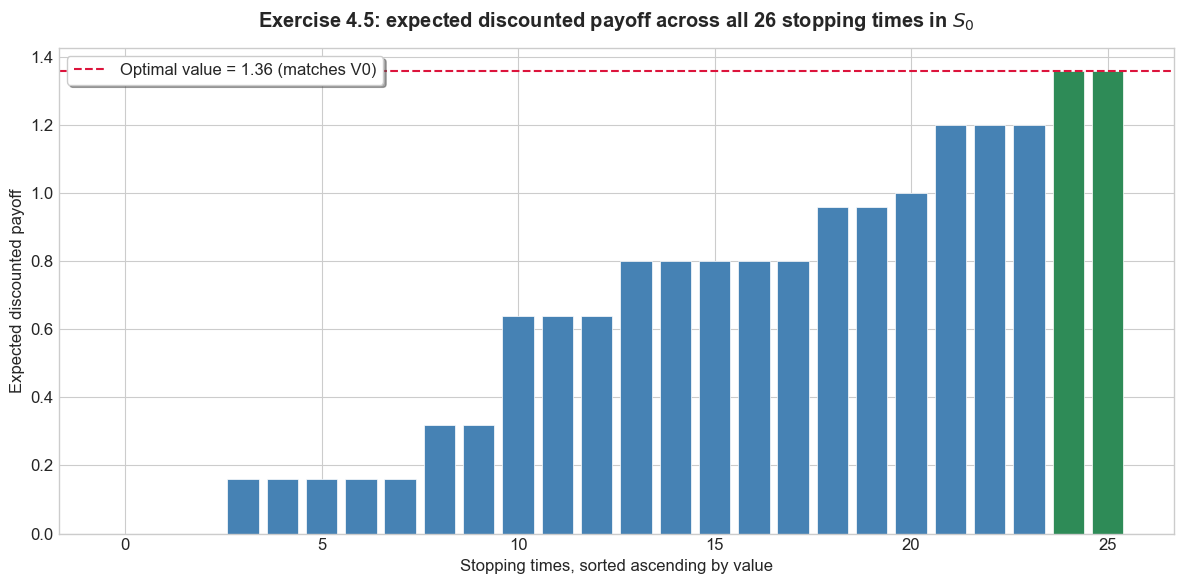


The book's stopping time from Eq. (4.4.6) is among the optimal ones: True


In [23]:
space_45 = CoinTossSpace(n_periods=2, p=p_tilde)
omega = space_45.get_omega()

possible_times = [0, 1, 2, float('inf')]

valid_taus = []
for combo in product(possible_times, repeat=len(omega)):
    tau_candidate = dict(zip(omega, combo))
    if is_stopping_time(space_45, tau_candidate):
        valid_taus.append(tau_candidate)

print(f"Number of valid stopping times in S_0: {len(valid_taus)}   (Exercise 4.5 states: 26)")
assert len(valid_taus) == 26

put_payoff = EuropeanPut(strike=5.0)

def expected_discounted_payoff(tau, model, space, payoff):
    total = 0.0
    for w in space.get_omega():
        t = tau[w]
        if t == float('inf'):
            continue
        t = int(t)
        s_t = model.price_path(w[:t])[-1]
        g_t = payoff.compute(np.array([s_t]))
        total += space.probability(w) * ((1 / (1 + model.r)) ** t) * g_t
    return total

values = [expected_discounted_payoff(tau, american_model, space_45, put_payoff) for tau in valid_taus]
sorted_values = sorted(values)

max_value = max(values)
print(f"\nMaximum expected discounted payoff across all 26 stopping times: {max_value:.4f}")
print(f"AmericanEngine.price(...).v0                                    : {american_result.v0:.4f}")
assert abs(max_value - american_result.v0) < 1e-9
print("✅ The definitional maximum over all stopping times matches the recursive algorithm exactly.")

colors = ['seagreen' if np.isclose(v, max_value, atol=1e-9) else 'steelblue' for v in sorted_values]

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(range(len(sorted_values)), sorted_values, color=colors, edgecolor='white', linewidth=0.5)
ax.axhline(y=max_value, color='crimson', linestyle='--', linewidth=1.5,
           label=f'Optimal value = {max_value:.2f} (matches V0)')
ax.set_title('Exercise 4.5: expected discounted payoff across all 26 stopping times in $S_0$',
             fontweight='bold', pad=15)
ax.set_xlabel('Stopping times, sorted ascending by value')
ax.set_ylabel('Expected discounted payoff')
ax.legend(loc='upper left', frameon=True, shadow=True)
plt.tight_layout()
plt.show()

book_tau = {"HH": float('inf'), "HT": 2.0, "TH": 1.0, "TT": 1.0}
book_tau_is_optimal = any(
    t == book_tau and np.isclose(expected_discounted_payoff(t, american_model, space_45, put_payoff), max_value)
    for t in valid_taus
)
print("\nThe book's stopping time from Eq. (4.4.6) is among the optimal ones:", book_tau_is_optimal)

### 5. Path-Dependent American Options: the Running-Average Put (Exercise 4.3)

Exercise 4.3 asks for an American security whose intrinsic value depends on the *running average* stock price — genuinely path-dependent, the way the Asian option was back in Chapter 1. The book gives no numeric answer, so we establish the price the same way the project always has for un-solved exercises: two independent computation routes. `AmericanEngine` combined with `RunningAveragePut` reuses the general Theorem 4.4.3 algorithm over the two-dimensional state $(S_n, Y_n)$; a direct brute-force backward induction over the full tree of histories gives the same answer with no shared code at all.

=== Exercise 4.3: American put on the running average price ===
AmericanEngine (recursive Theorem 4.4.3 algorithm) : 0.4000
Brute-force backward induction over full histories  : 0.4000
✅ Both computation routes agree exactly -- the book gives no number here, so this cross-validation is the answer.


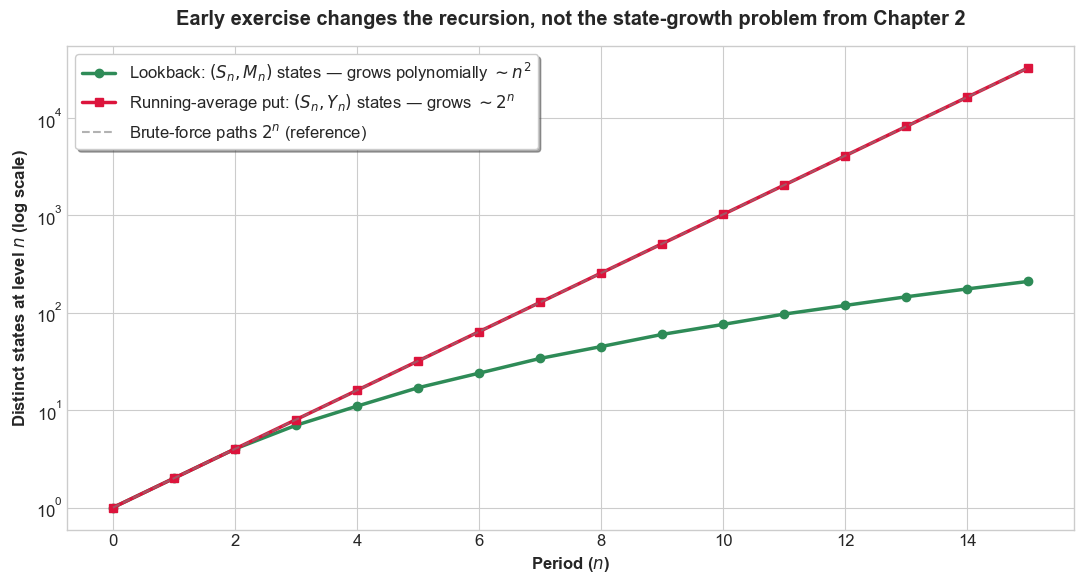


At n=15: Lookback keeps 210 states, running-average put needs 32768 out of 32768 possible paths (= 2^15) -- AmericanEngine adds a max() at every node ReducedStateEngine already builds, so a payoff that doesn't recombine under the European algorithm still won't recombine under the American one.


In [24]:
K_running_avg = 4.0
n_periods_43 = 3
running_avg_put = RunningAveragePut(strike=K_running_avg)

engine_v0 = AmericanEngine().price(american_model, running_avg_put, n_periods=n_periods_43).v0

omega_43 = CoinTossSpace(n_periods=n_periods_43, p=0.5).get_omega()  # only used to enumerate paths
discount = 1 / (1 + american_model.r)

brute_V = {w: max(K_running_avg - sum(american_model.price_path(w)) / (n_periods_43 + 1), 0.0) for w in omega_43}

for n in range(n_periods_43 - 1, -1, -1):
    prefixes = [""] if n == 0 else ["".join(seq) for seq in product("HT", repeat=n)]
    V_new = {}
    for prefix in prefixes:
        cont = discount * (p_tilde * brute_V[prefix + "H"] + q_tilde * brute_V[prefix + "T"])
        intrinsic = max(K_running_avg - sum(american_model.price_path(prefix)) / (n + 1), 0.0)
        V_new[prefix] = max(intrinsic, cont)
    brute_V = V_new

brute_v0 = brute_V[""]

print("=== Exercise 4.3: American put on the running average price ===")
print(f"AmericanEngine (recursive Theorem 4.4.3 algorithm) : {engine_v0:.4f}")
print(f"Brute-force backward induction over full histories  : {brute_v0:.4f}")
assert abs(engine_v0 - brute_v0) < 1e-9
print("✅ Both computation routes agree exactly -- the book gives no number here, so this cross-validation is the answer.")

n_scale = 15
levels = list(range(n_scale + 1))
counts_running_avg = count_states_per_level(scaling_model, RunningAveragePut(strike=0.0), n_scale)
counts_lookback = count_states_per_level(scaling_model, LookbackOption(), n_scale)
counts_brute = [2 ** n for n in levels]

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(levels, counts_lookback, 'o-', color='seagreen', linewidth=2.5,
        label=r'Lookback: $(S_n, M_n)$ states — grows polynomially $\sim n^2$')
ax.plot(levels, counts_running_avg, 's-', color='crimson', linewidth=2.5,
        label=r'Running-average put: $(S_n, Y_n)$ states — grows $\sim 2^n$')
ax.plot(levels, counts_brute, '--', color='gray', alpha=0.6, label=r'Brute-force paths $2^n$ (reference)')

ax.set_yscale('log')
ax.set_title('Early exercise changes the recursion, not the state-growth problem from Chapter 2',
             fontweight='bold', pad=15)
ax.set_xlabel('Period ($n$)', fontweight='bold')
ax.set_ylabel('Distinct states at level $n$ (log scale)', fontweight='bold')
ax.legend(loc='upper left', frameon=True, shadow=True)
plt.tight_layout()
plt.show()

print(f"\nAt n={n_scale}: Lookback keeps {counts_lookback[-1]} states, running-average put needs "
      f"{counts_running_avg[-1]} out of {counts_brute[-1]} possible paths (= 2^{n_scale}) -- "
      "AmericanEngine adds a max() at every node ReducedStateEngine already builds, so a payoff that "
      "doesn't recombine under the European algorithm still won't recombine under the American one.")

### 6. American Calls Are Never Exercised Early (Theorem 4.5.1)

Section 5 showed genuine path-dependent state growth; this section closes the chapter with the opposite kind of result — a case where the early-exercise machinery we just built turns out to add *nothing*. Across a full range of strikes, we compare the American and European prices of both a put and a call on the same non-dividend-paying stock. The put's early-exercise premium should be strictly positive and vary with the strike, exactly as Example 4.2.1 already hinted; the call's premium should be zero everywhere, to machine precision — Theorem 4.5.1's conclusion, verified not at one strike but across the whole curve.

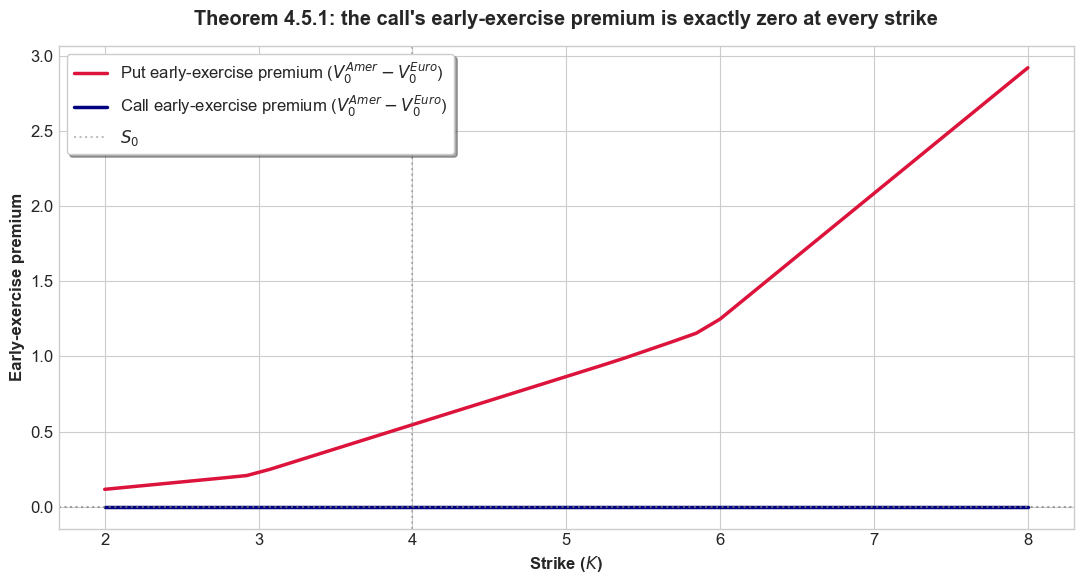

Max |call premium| across all strikes: 0.0
Min put premium across all strikes   : 0.1152

Sum of consumption across all nodes (K=5.0):
  American put  : 5.7632  (nonzero -- early exercise happens)
  American call : 0.0000  (must be exactly zero)

✅ Consumption is identically zero for the call at every node -- exactly Theorem 4.5.1's conclusion.


In [25]:
strikes = np.linspace(2.0, 8.0, 40)
n_periods_45 = 5

am_engine = AmericanEngine()
eu_engine = ReducedStateEngine()

put_premiums, call_premiums = [], []

for K in strikes:
    put_am = am_engine.price(american_model, EuropeanPut(strike=K), n_periods=n_periods_45)
    put_eu = eu_engine.price(american_model, EuropeanPut(strike=K), n_periods=n_periods_45)
    call_am = am_engine.price(american_model, EuropeanCall(strike=K), n_periods=n_periods_45)
    call_eu = eu_engine.price(american_model, EuropeanCall(strike=K), n_periods=n_periods_45)

    put_premiums.append(put_am.v0 - put_eu.v0)
    call_premiums.append(call_am.v0 - call_eu.v0)

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(strikes, put_premiums, color='crimson', linewidth=2.5,
        label=r'Put early-exercise premium ($V_0^{Amer}-V_0^{Euro}$)')
ax.plot(strikes, call_premiums, color='navy', linewidth=2.5,
        label=r'Call early-exercise premium ($V_0^{Amer}-V_0^{Euro}$)')
ax.axhline(y=0, color='gray', linestyle=':', alpha=0.7)
ax.axvline(x=american_model.s0, color='gray', linestyle=':', alpha=0.5, label='$S_0$')
ax.set_title(r"Theorem 4.5.1: the call's early-exercise premium is exactly zero at every strike",
             fontweight='bold', pad=15)
ax.set_xlabel('Strike ($K$)', fontweight='bold')
ax.set_ylabel('Early-exercise premium', fontweight='bold')
ax.legend(loc='upper left', frameon=True, shadow=True)
plt.tight_layout()
plt.show()

print("Max |call premium| across all strikes:", max(abs(p) for p in call_premiums))
print("Min put premium across all strikes   :", min(put_premiums))

K_check = 5.0
put_check = am_engine.price(american_model, EuropeanPut(strike=K_check), n_periods=n_periods_45)
call_check = am_engine.price(american_model, EuropeanCall(strike=K_check), n_periods=n_periods_45)

put_consumption_total = sum(put_check.consumption_grid.values())
call_consumption_total = sum(call_check.consumption_grid.values())

print(f"\nSum of consumption across all nodes (K={K_check}):")
print(f"  American put  : {put_consumption_total:.4f}  (nonzero -- early exercise happens)")
print(f"  American call : {call_consumption_total:.4f}  (must be exactly zero)")

assert abs(call_consumption_total) < 1e-9
print("\n✅ Consumption is identically zero for the call at every node -- exactly Theorem 4.5.1's conclusion.")

### 7. The Early-Exercise Boundary Across Time 

Theorem 4.4.5 says the optimal exercise rule is the first time the price equals the intrinsic value — but it says nothing about *where* that happens. For an American put, that boundary has a classic shape in continuous-time finance: a curve in $(n, s)$-space separating "exercise now" from "keep waiting," which rises toward the strike as expiration approaches. We don't need any new machinery to see this — `value_grid` already contains everything required. At each level $n$, the exercise region is every price where $v_n(s)$ equals the intrinsic value $g(s)>0$; we take the largest such price as that level's boundary, since the put's exercise region is always the low-price tail. Plotting the boundary against $n$ reproduces the same qualitative trend, with no extra assumptions beyond what's already in `value_grid` — no exercise near time zero, boundary approaching the strike near maturity — though the discrete lattice makes it a jagged rather than smooth curve, since $u \cdot d \neq 1$ here and each level's price grid shifts unevenly.

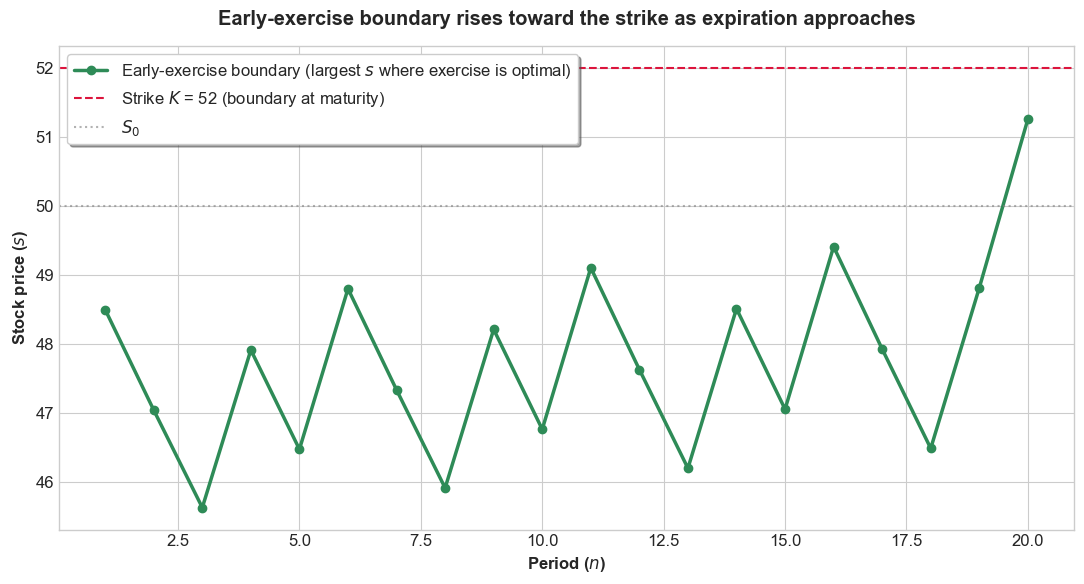

First period at which early exercise becomes optimal anywhere in the tree: n = 1
Boundary at n=0                : None
Boundary at n=20 (maturity) : 51.2561


In [26]:
K_boundary = 52.0
n_boundary = 20
boundary_model = BinomialStockModel(s0=50.0, u=1.05, d=0.97, r=0.01)
boundary_put = EuropeanPut(strike=K_boundary)

boundary_result = AmericanEngine().price(boundary_model, boundary_put, n_periods=n_boundary)

boundary_per_level = []
for n in range(n_boundary + 1):
    level_states = [(key[1], v) for key, v in boundary_result.value_grid.items() if key[0] == n]
    exercised_prices = [
        s for s, v in level_states
        if abs(v - max(K_boundary - s, 0.0)) < 1e-9 and (K_boundary - s) > 1e-9
    ]
    boundary_per_level.append(max(exercised_prices) if exercised_prices else None)

levels_plotted = [n for n, b in enumerate(boundary_per_level) if b is not None]
boundary_plotted = [b for b in boundary_per_level if b is not None]

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(levels_plotted, boundary_plotted, color='seagreen', marker='o', linewidth=2.5,
        label='Early-exercise boundary (largest $s$ where exercise is optimal)')
ax.axhline(y=K_boundary, color='crimson', linestyle='--', linewidth=1.5,
           label=f'Strike $K$ = {K_boundary:.0f} (boundary at maturity)')
ax.axhline(y=boundary_model.s0, color='gray', linestyle=':', alpha=0.6, label='$S_0$')

ax.set_title('Early-exercise boundary rises toward the strike as expiration approaches',
             fontweight='bold', pad=15)
ax.set_xlabel('Period ($n$)', fontweight='bold')
ax.set_ylabel('Stock price ($s$)', fontweight='bold')
ax.legend(loc='upper left', frameon=True, shadow=True)
plt.tight_layout()
plt.show()

first_exercise_level = next((n for n, b in enumerate(boundary_per_level) if b is not None), None)
print(f"First period at which early exercise becomes optimal anywhere in the tree: n = {first_exercise_level}")
print(f"Boundary at n=0                : {boundary_per_level[0]}")
print(f"Boundary at n={n_boundary} (maturity) : {boundary_per_level[n_boundary]:.4f}")